In [7]:
import pandas as pd
import numpy as np

# Display all columns
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 50)

# Load data
df_artists = pd.read_csv('/Users/jamesemcnally/Documents/GitHub/spring-2026-hitmakers/df_artists.csv')
df_songs   = pd.read_csv('/Users/jamesemcnally/Documents/GitHub/spring-2026-hitmakers/df_songs.csv')

print(f"df_artists:   {df_artists.shape}")
print(f"df_songs:     {df_songs.shape}")


df_artists:   (13609, 24)
df_songs:     (38383, 43)


In [9]:
# ============================================================================
# NETWORK METRICS PIPELINE
#
# Rebuilds the Billboard collaboration network from scratch using corrected
# MusicBrainz artist IDs, then computes year-by-year network metrics.
#
# Requires: MusicBrainz database running in Docker (docker ps to verify)
#
# PHASE 1 — Query MusicBrainz for all collaboration edges
# PHASE 2 — Build yearly + rolling-5-year network snapshots (1958–2024)
# PHASE 3 — Compute metrics and store in df_artists_network_metrics
#
# OUTPUT: df_artists_network_metrics.csv  (26 columns)
#   - name, musicbrainz_artist_id
#   - 20 centrality columns (5 metrics × 2 moments × 2 windows)
#   - 4 power columns       (1 metric  × 2 moments × 2 windows)
#
# POWER METRIC: sum of collaborator power scores within a time window.
#   Each collaborator's power = best chart peak (song or album) up to that year.
#   Song power  = 101 - peak_position         (scale: 1–100)
#   Album power = (201 - peak_position) / 2   (normalized to same 0–100 scale)
#   Per collaborator: take the better of song or album power.
#   Total: sum across all collaborators in the window.
# ============================================================================

import numpy as np
import networkx as nx
import psycopg2
from pathlib import Path
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

BASE_DIR     = Path('/Users/jamesemcnally/Documents/GitHub/spring-2026-hitmakers')
NETWORKS_DIR = BASE_DIR / 'networks_all_artists'
EDGE_OUT     = BASE_DIR / 'master_edge_list_all_artists.parquet'
METRICS_OUT  = BASE_DIR / 'df_artists_network_metrics.csv'

DB_PARAMS = {
    'dbname': 'musicbrainz_db', 'user': 'musicbrainz',
    'password': 'musicbrainz',  'host': 'localhost', 'port': 5432,
}

# ── PHASE 1: Rebuild master edge list ────────────────────────────────────────

print("PHASE 1: Querying MusicBrainz...")

artist_ids = (
    df_artists['musicbrainz_artist_id']
    .dropna().astype(float).astype(int).unique().tolist()
)
print(f"  Seed artists: {len(artist_ids):,}")

SQL = """
WITH EarliestRG AS (
    SELECT r.release_group, MIN(rc.date_year) AS first_year
    FROM release r
    JOIN release_country rc ON r.id = rc.release
    WHERE rc.date_year IS NOT NULL
    GROUP BY r.release_group
),
CollaborationEdges AS (
    SELECT acn1.artist AS artist_a, acn2.artist AS artist_b,
           rg.id AS release_group_id, erg.first_year
    FROM artist_credit_name acn1
    JOIN artist_credit_name acn2
        ON  acn1.artist_credit = acn2.artist_credit
        AND acn1.artist < acn2.artist
    JOIN release_group rg ON rg.artist_credit = acn1.artist_credit
    JOIN EarliestRG erg   ON rg.id = erg.release_group
    WHERE acn1.artist = ANY(%s::integer[])
)
SELECT * FROM CollaborationEdges;
"""

all_edges, BATCH_SIZE = [], 500
conn = psycopg2.connect(**DB_PARAMS)
conn.autocommit = True
with conn.cursor() as cur:
    for i in tqdm(range((len(artist_ids) + BATCH_SIZE - 1) // BATCH_SIZE), desc="  Querying"):
        cur.execute(SQL, (artist_ids[i*BATCH_SIZE:(i+1)*BATCH_SIZE],))
        all_edges.extend(cur.fetchall())
conn.close()

master_edges = (
    pd.DataFrame(all_edges, columns=['artist_a','artist_b','release_group_id','first_year'])
    .drop_duplicates(subset=['artist_a','artist_b','release_group_id'])
    .reset_index(drop=True)
)
print(f"  Edges: {len(master_edges):,}")
print(f"  Unique artists in network: {len(set(master_edges['artist_a']) | set(master_edges['artist_b'])):,}")
print(f"  Year range: {int(master_edges['first_year'].min())}–{int(master_edges['first_year'].max())}")
master_edges.to_parquet(EDGE_OUT, index=False)
print(f"  Saved → {EDGE_OUT}")

# ── PHASE 2: Build year-by-year snapshots ────────────────────────────────────

print("\nPHASE 2: Building snapshots (1958–2024)...")
for year in tqdm(range(1958, 2025), desc="  Snapshots"):
    d = NETWORKS_DIR / str(year)
    d.mkdir(parents=True, exist_ok=True)
    master_edges[master_edges['first_year'] == year][['artist_a','artist_b']].to_csv(
        d / 'yearly_snapshot.csv', index=False)
    master_edges[master_edges['first_year'].between(year - 4, year)][['artist_a','artist_b']].to_csv(
        d / 'rolling_5year.csv', index=False)
print(f"  Saved → {NETWORKS_DIR}")

# ── PHASE 3: Set up power metric helpers ─────────────────────────────────────

print("\nPHASE 3: Computing metrics...")

# Bidirectional adjacency lookup: artist_id → array of [neighbor_id, first_year]
edges_fwd         = master_edges[['artist_a','artist_b','first_year']].copy()
edges_fwd.columns = ['target','neighbor','first_year']
edges_rev         = master_edges[['artist_b','artist_a','first_year']].copy()
edges_rev.columns = ['target','neighbor','first_year']
adj_grouped = {
    target: grp[['neighbor','first_year']].values
    for target, grp in pd.concat([edges_fwd, edges_rev]).groupby('target')
}

# Cumulative best peak lookup: artist_id → array of [year, cumulative_best_peak]
def build_peak_lookup(df, id_col, year_col, peak_col):
    valid = df[df[id_col].notna()].copy()
    valid[id_col] = valid[id_col].astype(int)
    yearly = (
        valid.groupby([id_col, year_col])[peak_col].min()
        .reset_index().sort_values([id_col, year_col])
    )
    yearly['cumulative_best'] = yearly.groupby(id_col)[peak_col].cummin()
    return {int(aid): grp[[year_col,'cumulative_best']].values
            for aid, grp in yearly.groupby(id_col)}

song_peak_lookup  = build_peak_lookup(df_songs,  'musicbrainz_artist_id', 'first_charting_year', 'peak_pos')
album_peak_lookup = build_peak_lookup(df_albums, 'musicbrainz_artist_id', 'first_charting_year', 'peak_pos')
print(f"  Peak lookups: {len(song_peak_lookup):,} song artists, {len(album_peak_lookup):,} album artists")

def get_best_peak_as_of(lookup, artist_id, target_year):
    if artist_id not in lookup:
        return np.nan
    arr  = lookup[artist_id]
    mask = arr[:, 0] <= target_year
    return arr[mask, 1][-1] if mask.any() else np.nan

def compute_power(target_id, target_year, window):
    if target_id not in adj_grouped:
        return np.nan
    neighbors = adj_grouped[target_id]
    if window == 'yearly':
        mask = neighbors[:, 1] == target_year
    else:  # rolling5
        mask = (neighbors[:, 1] >= target_year - 4) & (neighbors[:, 1] <= target_year)
    valid = np.unique(neighbors[mask, 0])
    if len(valid) == 0:
        return np.nan
    total = 0.0
    for nid in valid:
        nid       = int(nid)
        song_pow  = (101 - get_best_peak_as_of(song_peak_lookup,  nid, target_year))
        album_pow = ((201 - get_best_peak_as_of(album_peak_lookup, nid, target_year)) / 2)
        candidates = [p for p in [song_pow, album_pow] if not np.isnan(p)]
        if candidates:
            total += max(candidates)
    return total if total > 0 else np.nan

# ── Initialize output dataframe ──────────────────────────────────────────────

METRICS       = ['degree','closeness','harmonic_closeness','betweenness','eigenvector']
NETWORK_TYPES = ['yearly','rolling5']

df_net = df_artists[['name','musicbrainz_artist_id']].copy()
df_net['_mb_id'] = pd.to_numeric(df_net['musicbrainz_artist_id'], errors='coerce').fillna(-1).astype(int)

for m in METRICS:
    for t in NETWORK_TYPES:
        df_net[f'{m}_centrality_top10_{t}']     = None
        df_net[f'{m}_centrality_firstsong_{t}'] = None
for t in NETWORK_TYPES:
    df_net[f'power_of_connected_artists_top10_{t}']     = None
    df_net[f'power_of_connected_artists_firstsong_{t}'] = None

# Year → row index maps
top10_map, firstsong_map = {}, {}
for idx, row in df_artists.iterrows():
    if pd.notna(row['first_year_top_10_songs']):
        top10_map.setdefault(int(row['first_year_top_10_songs']), []).append(idx)
    if pd.notna(row['first_song_year']):
        firstsong_map.setdefault(int(row['first_song_year']), []).append(idx)

def get_centrality(G):
    if len(G) == 0: return {m: {} for m in METRICS}
    out = {}
    try:    out['degree']             = nx.degree_centrality(G)
    except: out['degree']             = {}
    try:    out['closeness']          = nx.closeness_centrality(G)
    except: out['closeness']          = {}
    try:    out['harmonic_closeness'] = nx.harmonic_centrality(G)
    except: out['harmonic_closeness'] = {}
    try:    out['betweenness']        = nx.betweenness_centrality(G, k=min(len(G), 500))
    except: out['betweenness']        = {}
    try:    out['eigenvector']        = nx.eigenvector_centrality(G, max_iter=1000)
    except: out['eigenvector']        = {}
    return out

FILES = {'yearly': 'yearly_snapshot.csv', 'rolling5': 'rolling_5year.csv'}

# ── Main loop ─────────────────────────────────────────────────────────────────

for year in tqdm(sorted(set(top10_map) | set(firstsong_map)), desc="  Years"):
    for net_key, fname in FILES.items():
        fpath = NETWORKS_DIR / str(year) / fname
        if not fpath.exists(): continue
        try:
            edges = pd.read_csv(fpath)
            if edges.empty: continue
            metrics = get_centrality(nx.from_pandas_edgelist(edges, 'artist_a', 'artist_b'))

            for idx in top10_map.get(year, []):
                mb_id = df_net.at[idx, '_mb_id']
                if mb_id == -1: continue
                for m in METRICS:
                    df_net.at[idx, f'{m}_centrality_top10_{net_key}'] = metrics[m].get(mb_id)
                df_net.at[idx, f'power_of_connected_artists_top10_{net_key}'] = compute_power(mb_id, year, net_key)

            for idx in firstsong_map.get(year, []):
                mb_id = df_net.at[idx, '_mb_id']
                if mb_id == -1: continue
                for m in METRICS:
                    df_net.at[idx, f'{m}_centrality_firstsong_{net_key}'] = metrics[m].get(mb_id)
                df_net.at[idx, f'power_of_connected_artists_firstsong_{net_key}'] = compute_power(mb_id, year, net_key)

        except Exception as e:
            print(f"  Skipped {year}/{net_key}: {e}")

# ── Save ──────────────────────────────────────────────────────────────────────

df_artists_network_metrics = df_net.drop(columns=['_mb_id'])
df_artists_network_metrics.to_csv(METRICS_OUT, index=False)
print(f"\nDone. Saved → {METRICS_OUT}")
print(f"Shape: {df_artists_network_metrics.shape}")
print(f"\nCoverage:")
for col in ['degree_centrality_top10_rolling5',
            'power_of_connected_artists_top10_rolling5',
            'degree_centrality_firstsong_rolling5',
            'power_of_connected_artists_firstsong_rolling5']:
    n = df_artists_network_metrics[col].notna().sum()
    print(f"  {col}: {n} / {len(df_artists_network_metrics)} ({100*n/len(df_artists_network_metrics):.1f}%)")


PHASE 1: Querying MusicBrainz...
  Seed artists: 11,724


  Querying: 100%|██████████| 24/24 [06:09<00:00, 15.40s/it]


  Edges: 78,016
  Unique artists in network: 28,973
  Year range: 1926–2026
  Saved → /Users/jamesemcnally/Documents/GitHub/spring-2026-hitmakers/master_edge_list_all_artists.parquet

PHASE 2: Building snapshots (1958–2024)...


  Snapshots: 100%|██████████| 67/67 [00:00<00:00, 280.17it/s]


  Saved → /Users/jamesemcnally/Documents/GitHub/spring-2026-hitmakers/networks_all_artists

PHASE 3: Computing metrics...
  Peak lookups: 2,035 song artists, 1,641 album artists


  Years: 100%|██████████| 69/69 [05:52<00:00,  5.11s/it]


Done. Saved → /Users/jamesemcnally/Documents/GitHub/spring-2026-hitmakers/df_artists_network_metrics.csv
Shape: (14224, 26)

Coverage:
  degree_centrality_top10_rolling5: 678 / 14224 (4.8%)
  power_of_connected_artists_top10_rolling5: 479 / 14224 (3.4%)
  degree_centrality_firstsong_rolling5: 1743 / 14224 (12.3%)
  power_of_connected_artists_firstsong_rolling5: 1003 / 14224 (7.1%)


In [ ]:
# ======================================================
# REBUILD EDGE LIST: Add Track-Level Featuring Credits
# ======================================================
#
# The original edge list was built by looking at release-group
# credits in MusicBrainz — essentially the "album cover" level.
# This captures co-credited albums and singles, but misses
# featuring credits, which live at the individual track level
# (e.g., "Drake feat. Lil Wayne" on a track inside an album
# that is officially credited only to Drake).
#
# This cell runs two SQL queries against the local MusicBrainz
# PostgreSQL database (running in Docker):
#   1. The original release-group query (same as before)
#   2. A new track-level query that captures featuring credits
#
# The two are merged into one edge list. Where the same artist
# pair appears in both, the earliest year is kept. The result
# is saved back to master_edge_list_all_artists.parquet/.csv,
# replacing the old file.
# ======================================================

import pandas as pd
import numpy as np
import psycopg2

df_artists = pd.read_csv('df_artists.csv')
artist_ids = df_artists['musicbrainz_artist_id'].dropna().astype(int).tolist()

# ── Query 1: Release-group level (original) ──────────────────
RG_QUERY = """
WITH EarliestRG AS (
    SELECT r.release_group, MIN(rc.date_year) AS first_year
    FROM release r
    JOIN release_country rc ON r.id = rc.release
    WHERE rc.date_year IS NOT NULL
    GROUP BY r.release_group
),
CollaborationEdges AS (
    SELECT acn1.artist AS artist_a, acn2.artist AS artist_b,
           rg.id AS release_group_id, erg.first_year
    FROM artist_credit_name acn1
    JOIN artist_credit_name acn2
        ON acn1.artist_credit = acn2.artist_credit
        AND acn1.artist < acn2.artist
    JOIN release_group rg ON rg.artist_credit = acn1.artist_credit
    JOIN EarliestRG erg ON rg.id = erg.release_group
    WHERE acn1.artist = ANY(%s::integer[])
)
SELECT DISTINCT artist_a, artist_b, release_group_id, first_year
FROM CollaborationEdges;
"""

# ── Query 2: Track level (captures featuring credits) ────────
TRACK_QUERY = """
WITH TrackYear AS (
    SELECT t.artist_credit, MIN(rc.date_year) AS first_year
    FROM track t
    JOIN medium m ON t.medium = m.id
    JOIN release r ON m.release = r.id
    JOIN release_country rc ON r.id = rc.release
    WHERE rc.date_year IS NOT NULL
    GROUP BY t.artist_credit
),
CollaborationEdges AS (
    SELECT acn1.artist AS artist_a, acn2.artist AS artist_b,
           ty.artist_credit AS release_group_id, ty.first_year
    FROM artist_credit_name acn1
    JOIN artist_credit_name acn2
        ON acn1.artist_credit = acn2.artist_credit
        AND acn1.artist < acn2.artist
    JOIN TrackYear ty ON ty.artist_credit = acn1.artist_credit
    WHERE acn1.artist = ANY(%s::integer[])
)
SELECT DISTINCT artist_a, artist_b, release_group_id, first_year
FROM CollaborationEdges;
"""

conn = psycopg2.connect(
    host='localhost', port=5432,
    dbname='musicbrainz_db', user='musicbrainz', password='musicbrainz'
)

print("Running release-group query...")
with conn.cursor() as cur:
    cur.execute(RG_QUERY, (artist_ids,))
    rg_edges = pd.DataFrame(cur.fetchall(),
                            columns=['artist_a','artist_b','release_group_id','first_year'])
print(f"  Release-group edges: {len(rg_edges):,}")

print("Running track-level query (may take a few minutes)...")
with conn.cursor() as cur:
    cur.execute(TRACK_QUERY, (artist_ids,))
    track_edges = pd.DataFrame(cur.fetchall(),
                               columns=['artist_a','artist_b','release_group_id','first_year'])
print(f"  Track-level edges: {len(track_edges):,}")

conn.close()

# ── Merge: add track edges on top, keep earliest year per pair ─
rg_edges['source']    = 'release_group'
track_edges['source'] = 'track'

combined = pd.concat([rg_edges, track_edges], ignore_index=True)
combined = (combined
    .sort_values('first_year')
    .drop_duplicates(subset=['artist_a','artist_b'], keep='first'))

new_pairs = len(combined) - len(rg_edges.drop_duplicates(subset=['artist_a','artist_b']))
print(f"\nOriginal unique artist pairs: {len(rg_edges.drop_duplicates(subset=['artist_a','artist_b'])):,}")
print(f"New pairs added by track query: {new_pairs:,}")
print(f"Total unique pairs: {len(combined):,}")

# Check Drake and Beyoncé specifically because they have idiosyncratic collaboration patterns that were not captured in the initial code
id_to_name = df_artists.dropna(subset=['musicbrainz_artist_id']).drop_duplicates('musicbrainz_artist_id').set_index('musicbrainz_artist_id')['name'].to_dict()
for name, aid in [('Drake', 600808), ('Beyoncé', 422058)]:
    n = ((combined.artist_a == aid) | (combined.artist_b == aid)).sum()
    print(f"  {name}: {n} total collaboration edges")

combined.to_parquet('master_edge_list_all_artists.parquet', index=False)
combined.to_csv('master_edge_list_all_artists.csv', index=False)
print("\nSaved master_edge_list_all_artists.parquet/.csv")


Running release-group query...
  Release-group edges: 78,016
Running track-level query (may take a few minutes)...
  Track-level edges: 418,927

Original unique artist pairs: 51,582
New pairs added by track query: 161,947
Total unique pairs: 213,529
  Drake: 277 total collaboration edges
  Beyoncé: 234 total collaboration edges

Saved master_edge_list_all_artists.parquet/.csv


In [17]:
# ======================================================
# SUPPLEMENT EDGE LIST: Billboard Featuring Credits
# ======================================================
#
# Fix 1 extended the edge list using MusicBrainz track-level
# credits. This cell adds one more layer: featuring credits
# parsed directly from the Billboard performer strings in
# df_songs (e.g., "BLACKstreet (Featuring Dr. Dre)").
#
# This catches collaborations that are on Billboard but may
# not be fully catalogued in MusicBrainz — mixtapes, informal
# releases, and anything the database is missing.
#
# Rules applied based on manual review of all 62 "with" strings:
#   - "feat/featuring" strings: all parsed (536 strings, unambiguous)
#   - "with" strings: parsed, with three exceptions skipped because
#     the full string is itself a known artist name:
#       * "Jimmy Harnen With Synch"
#       * "Phil Phillips With The Twilights"
#       * "Pratt & McClain with Brother Love"
#   - "Duet With" strings: fixed with a separate regex pass so
#     "Duet" is not captured as part of the main artist name
#   - Compound main artists (e.g., "Skrillex & Diplo With Justin
#     Bieber") are resolved by splitting the left side on & or "and"
#
# Only adds pairs not already in the edge list. Saves back to
# master_edge_list_all_artists.parquet/.csv.
# ======================================================

import pandas as pd
import numpy as np
import re

df_songs   = pd.read_csv('df_songs.csv')
df_artists = pd.read_csv('df_artists.csv')

# ── Artist name → ID lookup (lowercase) ──────────────────────
name_to_id = (df_artists
              .dropna(subset=['musicbrainz_artist_id'])
              .drop_duplicates('name')
              .assign(name_lower=lambda x: x['name'].str.lower())
              .set_index('name_lower')['musicbrainz_artist_id']
              .astype(int).to_dict())

def lookup(name_str):
    """Return MusicBrainz ID for a name string, or None."""
    return name_to_id.get(name_str.strip().lower())

# ── Strings to skip: full string is a known artist name ──────
SKIP_FULL_STRINGS = {
    "jimmy harnen with synch",
    "phil phillips with the twilights",
    "pratt & McClain with brother love",
    "pratt & mccain with brother love",   # normalisation safety
}

# ── Parse a performer string → list of (artist_id, artist_id) ─
def extract_pairs(performer_str):
    """
    Returns a list of (id_a, id_b) int tuples representing
    collaboration edges found in a single performer string.
    """
    if pd.isna(performer_str):
        return []

    s = performer_str.strip()

    # Skip strings whose full form is a known artist name
    if s.lower() in SKIP_FULL_STRINGS:
        return []

    pairs = []

    # ── Pattern 1: feat / featuring ───────────────────────────
    # Handles: "X (Featuring Y)", "X Feat. Y", "X featuring Y & Z"
    m = re.match(
        r'^(.+?)\s*[\(\[]?[Ff]eat(?:uring)?\.?\s+(.+?)[\)\]]?\s*$', s)
    if m:
        main_str     = m.group(1).strip()
        featured_str = m.group(2).strip()
        main_ids     = resolve_compound(main_str)
        feat_ids     = resolve_compound(featured_str)
        for a in main_ids:
            for b in feat_ids:
                if a and b and a != b:
                    pairs.append(tuple(sorted([a, b])))
        return pairs

    # ── Pattern 2: (Duet With) / (Duet with) ─────────────────
    # Handles: "Jordin Sparks Duet With Chris Brown",
    #          "Dan Hill (Duet With Vonda Shepard)"
    m = re.match(
        r'^(.+?)\s*[\(\[]?(?:A\s+)?[Dd]uet\s+[Ww]ith\s+(.+?)[\)\]]?\s*$', s)
    if m:
        main_ids = resolve_compound(m.group(1).strip())
        feat_ids = resolve_compound(m.group(2).strip())
        for a in main_ids:
            for b in feat_ids:
                if a and b and a != b:
                    pairs.append(tuple(sorted([a, b])))
        return pairs

    # ── Pattern 3: with (plain) ───────────────────────────────
    # Handles: "Philip Bailey With Phil Collins",
    #          "Stevie Nicks With Don Henley"
    m = re.match(
        r'^(.+?)\s*[\(\[]?\bwith\b\s+(.+?)[\)\]]?\s*$', s, re.IGNORECASE)
    if m:
        main_ids = resolve_compound(m.group(1).strip())
        feat_ids = resolve_compound(m.group(2).strip())
        for a in main_ids:
            for b in feat_ids:
                if a and b and a != b:
                    pairs.append(tuple(sorted([a, b])))
        return pairs

    return pairs


def resolve_compound(name_str):
    """
    Try to resolve a name string to one or more artist IDs.
    Handles compound credits like "Skrillex & Diplo" or
    "Leon Russell & The Shelter People" by first trying the
    full string, then splitting on & / and.
    """
    ids = []
    direct = lookup(name_str)
    if direct:
        return [direct]
    # Try splitting on & or " and "
    parts = re.split(r'\s*&\s*|\s+[Aa]nd\s+', name_str)
    if len(parts) > 1:
        for part in parts:
            pid = lookup(part.strip())
            if pid:
                ids.append(pid)
    return ids


# ── Run over both performer columns ──────────────────────────
billboard_rows = []
for _, row in df_songs.iterrows():
    year = row.get('first_charting_year')
    if pd.isna(year):
        continue
    year = int(year)

    seen_this_row = set()
    for col in ['performer', 'original_performer']:
        for id_a, id_b in extract_pairs(row[col]):
            key = (id_a, id_b)
            if key not in seen_this_row:
                seen_this_row.add(key)
                billboard_rows.append({
                    'artist_a':        id_a,
                    'artist_b':        id_b,
                    'release_group_id': -1,   # marks Billboard origin
                    'first_year':       year,
                    'source':          'billboard'
                })

df_bb = (pd.DataFrame(billboard_rows)
         .sort_values('first_year')
         .drop_duplicates(subset=['artist_a','artist_b'], keep='first'))

print(f"Billboard featuring edges parsed: {len(df_bb):,}")

# ── Merge into existing edge list ────────────────────────────
existing = pd.read_parquet('master_edge_list_all_artists.parquet')
existing_pairs = set(zip(existing['artist_a'], existing['artist_b']))

# Only keep Billboard edges that aren't already in the list
new_bb = df_bb[~df_bb.apply(
    lambda r: (r['artist_a'], r['artist_b']) in existing_pairs, axis=1)]

print(f"New pairs not already in edge list: {len(new_bb):,}")

combined = (pd.concat([existing, new_bb], ignore_index=True)
            .sort_values('first_year')
            .drop_duplicates(subset=['artist_a','artist_b'], keep='first'))

print(f"Final edge list size: {len(combined):,} unique pairs")

# Spot-check Drake and Beyoncé
for name, aid in [('Drake', 600808), ('Beyoncé', 422058)]:
    n = ((combined.artist_a == aid) | (combined.artist_b == aid)).sum()
    print(f"  {name}: {n} edges")

combined.to_parquet('master_edge_list_all_artists.parquet', index=False)
combined.to_csv('master_edge_list_all_artists.csv', index=False)
print("\nSaved master_edge_list_all_artists.parquet/.csv")


Billboard featuring edges parsed: 509
New pairs not already in edge list: 51
Final edge list size: 213,580 unique pairs
  Drake: 277 edges
  Beyoncé: 234 edges

Saved master_edge_list_all_artists.parquet/.csv


## Create network metrics dataframe

In [3]:
# Install networkx in the current Jupyter kernel
import sys
!{sys.executable} -m pip install networkx


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 23.4 MB/s  0:00:00


In [9]:
# ======================================================
# REBUILD NETWORK SNAPSHOTS & METRICS
#
# Fixes vs. previous version:
#   - master_edges uses integer artist IDs as graph nodes.
#     df_songs only has UUID musicbrainz_artist_id, so we
#     build a uuid→int mapping via df_artists before calling
#     build_peak_lookup, ensuring integer IDs match graph nodes.
#   - df_albums_old.csv (not df_albums.csv)
#   - first_top_20_hit_year (not first_year_top_10_songs)
#   - top10 → top20 in all output column names
# ======================================================

import pandas as pd
import numpy as np
import networkx as nx
from pathlib import Path
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

BASE_DIR     = Path('/Users/jamesemcnally/Documents/GitHub/spring-2026-hitmakers')
NETWORKS_DIR = BASE_DIR / 'networks_all_artists'
EDGE_FILE    = BASE_DIR / 'master_edge_list_all_artists.parquet'
METRICS_OUT  = BASE_DIR / 'df_artists_network_metrics.csv'

df_artists = pd.read_csv(BASE_DIR / 'df_artists.csv')
df_songs   = pd.read_csv(BASE_DIR / 'df_songs.csv')
df_albums  = pd.read_csv(BASE_DIR / 'df_albums_old.csv')

# Load updated edge list (integer artist IDs throughout)
master_edges = pd.read_parquet(EDGE_FILE)
print(f"Edge list loaded: {len(master_edges):,} edges")
print(f"Year range: {int(master_edges['first_year'].min())}–{int(master_edges['first_year'].max())}")

# ── PHASE 2: Build year-by-year snapshots ────────────────────

print("\nPHASE 2: Building snapshots (1958–2024)...")
NETWORKS_DIR.mkdir(parents=True, exist_ok=True)

for year in tqdm(range(1958, 2025), desc="  Snapshots"):
    d = NETWORKS_DIR / str(year)
    d.mkdir(parents=True, exist_ok=True)
    master_edges[master_edges['first_year'] == year][['artist_a','artist_b']].to_csv(
        d / 'yearly_snapshot.csv', index=False)
    master_edges[master_edges['first_year'].between(year - 4, year)][['artist_a','artist_b']].to_csv(
        d / 'rolling_5year.csv', index=False)

print(f"  Saved snapshots → {NETWORKS_DIR}")

# ── PHASE 3: Power metric helpers ────────────────────────────

print("\nPHASE 3: Computing metrics...")

# Bidirectional adjacency: integer artist_id → array of [neighbor_id, first_year]
edges_fwd = master_edges[['artist_a','artist_b','first_year']].rename(
    columns={'artist_a':'target','artist_b':'neighbor'})
edges_rev = master_edges[['artist_b','artist_a','first_year']].rename(
    columns={'artist_b':'target','artist_a':'neighbor'})
adj_grouped = {
    target: grp[['neighbor','first_year']].values
    for target, grp in pd.concat([edges_fwd, edges_rev]).groupby('target')
}

# Build UUID → integer ID mapping from df_artists.
# master_edges uses integer musicbrainz_artist_id as node keys.
# df_songs only has the UUID version, so we map through df_artists.
uuid_to_int = (
    df_artists[['musicbrainz_mbid','musicbrainz_artist_id']]
    .dropna(subset=['musicbrainz_mbid','musicbrainz_artist_id'])
    .set_index('musicbrainz_mbid')['musicbrainz_artist_id']
    .apply(lambda x: int(x))
    .to_dict()
)
df_songs_mapped = df_songs.copy()
df_songs_mapped['_int_id'] = df_songs_mapped['musicbrainz_artist_id'].map(uuid_to_int)
print(f"  UUID→int mapped: {df_songs_mapped['_int_id'].notna().sum():,} / {len(df_songs_mapped):,} songs")

# Cumulative best peak lookup: integer artist_id → array of [year, cumulative_best_peak]
def build_peak_lookup(df, id_col, year_col, peak_col):
    valid = df[df[id_col].notna()].copy()
    valid[id_col] = valid[id_col].astype(int)
    yearly = (valid.groupby([id_col, year_col])[peak_col].min()
              .reset_index().sort_values([id_col, year_col]))
    yearly['cumulative_best'] = yearly.groupby(id_col)[peak_col].cummin()
    return {int(aid): grp[[year_col,'cumulative_best']].values
            for aid, grp in yearly.groupby(id_col)}

song_peak_lookup  = build_peak_lookup(df_songs_mapped, '_int_id', 'first_charting_year', 'peak_pos')
album_peak_lookup = build_peak_lookup(df_albums, 'musicbrainz_artist_id', 'first_charting_year', 'peak_pos')
print(f"  Peak lookups: {len(song_peak_lookup):,} song artists, {len(album_peak_lookup):,} album artists")

def get_best_peak_as_of(lookup, artist_id, target_year):
    if artist_id not in lookup: return np.nan
    arr  = lookup[artist_id]
    mask = arr[:, 0] <= target_year
    return arr[mask, 1][-1] if mask.any() else np.nan

def compute_power(target_id, target_year, window):
    if target_id not in adj_grouped: return np.nan
    neighbors = adj_grouped[target_id]
    mask = (neighbors[:, 1] == target_year) if window == 'yearly' else \
           ((neighbors[:, 1] >= target_year - 4) & (neighbors[:, 1] <= target_year))
    valid = np.unique(neighbors[mask, 0])
    if len(valid) == 0: return np.nan
    total = 0.0
    for nid in valid:
        nid       = int(nid)
        song_pow  = 101  - get_best_peak_as_of(song_peak_lookup,  nid, target_year)
        album_pow = (201 - get_best_peak_as_of(album_peak_lookup, nid, target_year)) / 2
        candidates = [p for p in [song_pow, album_pow] if not np.isnan(p)]
        if candidates: total += max(candidates)
    return total if total > 0 else np.nan

# ── Initialize output dataframe ──────────────────────────────

METRICS       = ['degree','closeness','harmonic_closeness','betweenness','eigenvector']
NETWORK_TYPES = ['yearly','rolling5']

# _mb_id = integer musicbrainz_artist_id, matching graph node IDs from master_edges
df_net = df_artists[['name','musicbrainz_artist_id']].copy()
df_net['_mb_id'] = pd.to_numeric(df_net['musicbrainz_artist_id'], errors='coerce').fillna(-1).astype(int)

for m in METRICS:
    for t in NETWORK_TYPES:
        df_net[f'{m}_centrality_top20_{t}']     = None
        df_net[f'{m}_centrality_firstsong_{t}'] = None
for t in NETWORK_TYPES:
    df_net[f'power_of_connected_artists_top20_{t}']     = None
    df_net[f'power_of_connected_artists_firstsong_{t}'] = None

# Year → row index maps
top20_map, firstsong_map = {}, {}
for idx, row in df_artists.iterrows():
    if pd.notna(row['first_top_20_hit_year']):
        top20_map.setdefault(int(row['first_top_20_hit_year']), []).append(idx)
    if pd.notna(row['first_song_year']):
        firstsong_map.setdefault(int(row['first_song_year']), []).append(idx)

def get_centrality(G):
    if len(G) == 0: return {m: {} for m in METRICS}
    out = {}
    try:    out['degree']             = nx.degree_centrality(G)
    except: out['degree']             = {}
    try:    out['closeness']          = nx.closeness_centrality(G)
    except: out['closeness']          = {}
    try:    out['harmonic_closeness'] = nx.harmonic_centrality(G)
    except: out['harmonic_closeness'] = {}
    try:    out['betweenness']        = nx.betweenness_centrality(G, k=min(len(G), 500))
    except: out['betweenness']        = {}
    try:    out['eigenvector']        = nx.eigenvector_centrality(G, max_iter=1000)
    except: out['eigenvector']        = {}
    return out

FILES = {'yearly': 'yearly_snapshot.csv', 'rolling5': 'rolling_5year.csv'}

# ── Main loop ─────────────────────────────────────────────────

for year in tqdm(sorted(set(top20_map) | set(firstsong_map)), desc="  Years"):
    for net_key, fname in FILES.items():
        fpath = NETWORKS_DIR / str(year) / fname
        if not fpath.exists(): continue
        try:
            edges = pd.read_csv(fpath)
            if edges.empty: continue
            G       = nx.from_pandas_edgelist(edges, 'artist_a', 'artist_b')
            metrics = get_centrality(G)

            for idx in top20_map.get(year, []):
                mb_id = df_net.at[idx, '_mb_id']
                if mb_id == -1: continue
                for m in METRICS:
                    df_net.at[idx, f'{m}_centrality_top20_{net_key}'] = metrics[m].get(mb_id)
                df_net.at[idx, f'power_of_connected_artists_top20_{net_key}'] = \
                    compute_power(mb_id, year, net_key)

            for idx in firstsong_map.get(year, []):
                mb_id = df_net.at[idx, '_mb_id']
                if mb_id == -1: continue
                for m in METRICS:
                    df_net.at[idx, f'{m}_centrality_firstsong_{net_key}'] = metrics[m].get(mb_id)
                df_net.at[idx, f'power_of_connected_artists_firstsong_{net_key}'] = \
                    compute_power(mb_id, year, net_key)

        except Exception as e:
            print(f"  Skipped {year}/{net_key}: {e}")

# ── Save ──────────────────────────────────────────────────────

df_artists_network_metrics = df_net.drop(columns=['_mb_id'])
df_artists_network_metrics.to_csv(METRICS_OUT, index=False)
print(f"\nDone. Saved → {METRICS_OUT}")
print(f"Shape: {df_artists_network_metrics.shape}")
print(f"\nCoverage (non-null):")
for col in ['degree_centrality_top20_rolling5',
            'power_of_connected_artists_top20_rolling5',
            'degree_centrality_firstsong_rolling5',
            'power_of_connected_artists_firstsong_rolling5']:
    n = df_artists_network_metrics[col].notna().sum()
    print(f"  {col}: {n:,} / {len(df_artists_network_metrics):,} ({100*n/len(df_artists_network_metrics):.1f}%)")


Edge list loaded: 213,580 edges
Year range: 1925–2026

PHASE 2: Building snapshots (1958–2024)...


  Snapshots: 100%|██████████| 67/67 [00:00<00:00, 138.83it/s]


  Saved snapshots → /Users/jamesemcnally/Documents/GitHub/spring-2026-hitmakers/networks_all_artists

PHASE 3: Computing metrics...
  UUID→int mapped: 35,122 / 38,383 songs
  Peak lookups: 7,294 song artists, 1,641 album artists


  Years: 100%|██████████| 69/69 [2:50:01<00:00, 147.84s/it]   


Done. Saved → /Users/jamesemcnally/Documents/GitHub/spring-2026-hitmakers/df_artists_network_metrics.csv
Shape: (13609, 26)

Coverage (non-null):
  degree_centrality_top20_rolling5: 1,298 / 13,609 (9.5%)
  power_of_connected_artists_top20_rolling5: 1,052 / 13,609 (7.7%)
  degree_centrality_firstsong_rolling5: 2,742 / 13,609 (20.1%)
  power_of_connected_artists_firstsong_rolling5: 2,116 / 13,609 (15.5%)


## EDA

In [14]:
df_artists_network_metrics.head()

,name,musicbrainz_artist_id,degree_centrality_top20_yearly,degree_centrality_firstsong_yearly,degree_centrality_top20_rolling5,degree_centrality_firstsong_rolling5,closeness_centrality_top20_yearly,closeness_centrality_firstsong_yearly,closeness_centrality_top20_rolling5,closeness_centrality_firstsong_rolling5,harmonic_closeness_centrality_top20_yearly,harmonic_closeness_centrality_firstsong_yearly,harmonic_closeness_centrality_top20_rolling5,harmonic_closeness_centrality_firstsong_rolling5,betweenness_centrality_top20_yearly,betweenness_centrality_firstsong_yearly,betweenness_centrality_top20_rolling5,betweenness_centrality_firstsong_rolling5,eigenvector_centrality_top20_yearly,eigenvector_centrality_firstsong_yearly,eigenvector_centrality_top20_rolling5,eigenvector_centrality_firstsong_rolling5,power_of_connected_artists_top20_yearly,power_of_connected_artists_firstsong_yearly,power_of_connected_artists_top20_rolling5,power_of_connected_artists_firstsong_rolling5
0,!!! (chk chk chk),NaN,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
1,"""groove"" holmes",NaN,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
2,"""little"" jimmy dickens",NaN,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
3,"""pookie"" hudson",232958.0,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,NaN,None,NaN
4,"""weird al"" yankovic",NaN,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None


In [16]:
# Check multicollinearity among the 5 centrality metrics (top20, rolling 5-year window)
# via correlation matrix and Variance Inflation Factors (VIF).
# Casts columns to float to handle None values stored as object dtype.

import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

cols = [
    'degree_centrality_top20_rolling5',
    'closeness_centrality_top20_rolling5',
    'harmonic_closeness_centrality_top20_rolling5',
    'betweenness_centrality_top20_rolling5',
    'eigenvector_centrality_top20_rolling5',
]

data = df_artists_network_metrics[cols].apply(pd.to_numeric, errors='coerce').dropna()

print(f"Rows used: {len(data):,}")
print("\n── Correlation Matrix ──")
print(data.corr().round(3).to_string())

print("\n── Variance Inflation Factors ──")
vif = pd.DataFrame({
    'feature': cols,
    'VIF': [variance_inflation_factor(data.values, i) for i in range(len(cols))]
})
print(vif.to_string(index=False))


Rows used: 1,298

── Correlation Matrix ──
                                              degree_centrality_top20_rolling5  closeness_centrality_top20_rolling5  harmonic_closeness_centrality_top20_rolling5  betweenness_centrality_top20_rolling5  eigenvector_centrality_top20_rolling5
degree_centrality_top20_rolling5                                         1.000                               -0.007                                        -0.070                                  0.622                                  0.367
closeness_centrality_top20_rolling5                                     -0.007                                1.000                                         0.910                                  0.127                                  0.414
harmonic_closeness_centrality_top20_rolling5                            -0.070                                0.910                                         1.000                                  0.038                                  0.4

In [20]:
# ======================================================
# STATISTICAL ANALYSIS: Network Metrics vs. OHW / Hitmaker Status
# Yearly vs. Rolling-5, by Decade and 5-Year Period
# ======================================================
#
# Tests whether hitmakers had significantly higher network
# centrality and power at their first top-10 year compared
# to one-hit wonders. Runs for both the yearly snapshot
# (edges from that year only) and the rolling-5 window
# (edges from the past 5 years), so you can see whether
# the window choice changes the story.
#
# Three outcome comparisons:
#   Top-10 — 1 top-10 song (OHW) vs. 2+ (HM)
#   Top-20 — 1 top-20 song (OHW) vs. 2+ (HM)
#   #1 Hit — 1 #1 song (OHW)    vs. 2+ (HM)
#
# For each metric × outcome × window × time period:
#   - Mann-Whitney U test
#   - Cohen's d (positive = hitmakers score higher)
#   - Means for each group
# ======================================================

import pandas as pd
import numpy as np
from scipy import stats

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

# ── Load & merge ─────────────────────────────────────────────
df_metrics = pd.read_csv('df_artists_network_metrics.csv')
df_artists = pd.read_csv('df_artists.csv')
df_songs   = pd.read_csv('df_songs.csv')

top20 = (df_songs.groupby('name')['peak_pos']
         .apply(lambda x: (x <= 20).sum(), include_groups=False)
         .rename('top_20_song_count'))
num1  = (df_songs.groupby('name')['peak_pos']
         .apply(lambda x: (x == 1).sum(), include_groups=False)
         .rename('num1_song_count'))
df_extra = pd.concat([top20, num1], axis=1).reset_index()
df_extra['top_20_1hit_wonder_song'] = df_extra['top_20_song_count'] == 1
df_extra['top_20_hitmaker_songs']   = df_extra['top_20_song_count'] >= 2
df_extra['num1_1hit_wonder_song']   = df_extra['num1_song_count'] == 1
df_extra['num1_hitmaker_songs']     = df_extra['num1_song_count'] >= 2

df = (df_metrics
      .merge(df_artists[['name', 'first_year_top_10_songs',
                          'top_10_1hit_wonder_song', 'top_10_hitmaker_songs']],
             on='name', how='left')
      .merge(df_extra, on='name', how='left'))

# ── Config ───────────────────────────────────────────────────
metrics = ['degree_centrality',
           'closeness_centrality',
           'harmonic_closeness_centrality',
           'betweenness_centrality',
           'eigenvector_centrality',
           'power_of_connected_artists']
metric_labels = ['Degree', 'Closeness', 'Harmonic Closeness',
                 'Betweenness', 'Eigenvector', 'Power']

outcomes = [
    ('top_10_1hit_wonder_song', 'top_10_hitmaker_songs', 'Top-10'),
    ('top_20_1hit_wonder_song', 'top_20_hitmaker_songs', 'Top-20'),
    ('num1_1hit_wonder_song',   'num1_hitmaker_songs',   '#1 Hit'),
]

windows = [('yearly', 'Yearly'), ('rolling5', 'Rolling-5')]

decades = [(1960,1969),(1970,1979),(1980,1989),(1990,1999),
           (2000,2009),(2010,2019),(2020,2029)]
decade_labels = ['1960s','1970s','1980s','1990s','2000s','2010s','2020s']

periods = [(1991,1995),(1996,2000),(2001,2005),
           (2006,2010),(2011,2015),(2016,2020)]
period_labels = [f'{s}–{e}' for s,e in periods]

def cohen_d(a, b):
    na, nb = len(a), len(b)
    if na < 2 or nb < 2: return np.nan
    sd = np.sqrt(((na-1)*np.var(a,ddof=1)+(nb-1)*np.var(b,ddof=1))/(na+nb-2))
    return (np.mean(a) - np.mean(b)) / sd if sd else np.nan

def sig_stars(p):
    if pd.isna(p):  return '—'
    if p < 0.001:   return '***'
    if p < 0.01:    return '**'
    if p < 0.05:    return '*'
    if p < 0.10:    return '~'
    return 'n.s.'

def run_analysis(df, ohw_col, hm_col, time_ranges, time_labels, window_key):
    rows = []
    for (start, end), time_lbl in zip(time_ranges, time_labels):
        mask = ((df['first_year_top_10_songs'] >= start) &
                (df['first_year_top_10_songs'] <= end))
        sub = df[mask].copy()
        for metric, mlbl in zip(metrics, metric_labels):
            col = f'{metric}_top10_{window_key}'
            if col not in sub.columns: continue
            sub[col] = sub[col].fillna(0)
            ohw_vals = sub[sub[ohw_col] == True][col].values
            hm_vals  = sub[sub[hm_col]  == True][col].values
            if len(ohw_vals) < 2 or len(hm_vals) < 2: continue
            _, p = stats.mannwhitneyu(hm_vals, ohw_vals, alternative='two-sided')
            d = cohen_d(hm_vals, ohw_vals)
            rows.append({
                'Period':    time_lbl,
                'Metric':    mlbl,
                'n_OHW':     len(ohw_vals),
                'n_HM':      len(hm_vals),
                'Mean OHW':  ohw_vals.mean(),
                'Mean HM':   hm_vals.mean(),
                'Cohen d':   d,
                'p-value':   p,
                'sig':       sig_stars(p),
            })
    return pd.DataFrame(rows)

# ── SECTION 1: Decade-by-decade ──────────────────────────────
print('=' * 80)
print('SECTION 1: DECADE-BY-DECADE — Yearly vs. Rolling-5')
print('=' * 80)

for ohw_col, hm_col, outcome_lbl in outcomes:
    print(f'\n{"─"*80}')
    print(f'  Outcome: {outcome_lbl}')
    print(f'{"─"*80}')

    for win_key, win_lbl in windows:
        res = run_analysis(df, ohw_col, hm_col, decades, decade_labels, win_key)
        if res.empty: continue
        print(f'\n  [{win_lbl}]')
        print(res.sort_values(['Period','Cohen d'], ascending=[True,False])
                 .to_string(index=False))

# ── SECTION 2: 5-year period breakdown ───────────────────────
print('\n\n' + '=' * 80)
print('SECTION 2: 5-YEAR PERIODS (1991–2020) — Yearly vs. Rolling-5')
print('=' * 80)

for ohw_col, hm_col, outcome_lbl in outcomes:
    print(f'\n{"─"*80}')
    print(f'  Outcome: {outcome_lbl}')
    print(f'{"─"*80}')

    for win_key, win_lbl in windows:
        res = run_analysis(df, ohw_col, hm_col, periods, period_labels, win_key)
        if res.empty: continue
        print(f'\n  [{win_lbl}]')
        print(res.sort_values(['Period','Cohen d'], ascending=[True,False])
                 .to_string(index=False))

# ── SECTION 3: Yearly vs Rolling-5 direct comparison ─────────
print('\n\n' + '=' * 80)
print('SECTION 3: YEARLY vs. ROLLING-5 — Do they tell different stories?')
print('=' * 80)

for ohw_col, hm_col, outcome_lbl in outcomes:
    print(f'\n  Outcome: {outcome_lbl}')

    y_res  = run_analysis(df, ohw_col, hm_col, periods, period_labels, 'yearly')
    r5_res = run_analysis(df, ohw_col, hm_col, periods, period_labels, 'rolling5')

    if y_res.empty or r5_res.empty: continue

    # Merge on Period × Metric
    comp = y_res[['Period','Metric','Cohen d','p-value']].merge(
        r5_res[['Period','Metric','Cohen d','p-value']],
        on=['Period','Metric'], suffixes=(' Yearly',' R5'))

    # Paired comparison across all period × metric combinations
    paired = comp.dropna(subset=['Cohen d Yearly','Cohen d R5'])
    t_stat, t_p = stats.ttest_rel(paired['Cohen d Yearly'], paired['Cohen d R5'])
    r, r_p = stats.pearsonr(paired['Cohen d Yearly'], paired['Cohen d R5'])
    diff = paired['Cohen d Yearly'] - paired['Cohen d R5']

    print(f'    Paired t-test (Yearly vs Rolling-5 Cohen\'s d): '
          f't={t_stat:.3f}, p={t_p:.4f}')
    print(f'    Mean difference (Yearly − Rolling-5):          '
          f'{diff.mean():.4f} (SD={diff.std():.4f})')
    print(f'    Correlation between windows:                   '
          f'r={r:.3f}, p={r_p:.4f}')
    print(f'    Interpretation: '
          f'{"Windows highly correlated — same story" if r > 0.8 else "Windows diverge — rolling-5 adds information"}')

    # Cases where they disagree on significance
    comp['y_sig']  = comp['p-value Yearly'] < 0.05
    comp['r5_sig'] = comp['p-value R5']     < 0.05
    disagree = comp[comp['y_sig'] != comp['r5_sig']]
    if len(disagree):
        print(f'\n    Cases where only one window is significant ({len(disagree)}):')
        for _, row in disagree.iterrows():
            winner = 'Yearly' if row['y_sig'] else 'Rolling-5'
            print(f'      {row["Period"]} / {row["Metric"]:22s} '
                  f'→ only {winner} sig  '
                  f'(d_Y={row["Cohen d Yearly"]:.3f}, d_R5={row["Cohen d R5"]:.3f})')
    else:
        print(f'\n    No cases where windows disagree on significance.')

# ── SECTION 4: Summary table ──────────────────────────────────
print('\n\n' + '=' * 80)
print('SECTION 4: SUMMARY — Significant metrics per period × window (p < .05)')
print('=' * 80)

all_rows = []
for ohw_col, hm_col, outcome_lbl in outcomes:
    for win_key, win_lbl in windows:
        res = run_analysis(df, ohw_col, hm_col, periods, period_labels, win_key)
        if res.empty: continue
        res['Outcome'] = outcome_lbl
        res['Window']  = win_lbl
        all_rows.append(res)

df_all = pd.concat(all_rows, ignore_index=True)

summary = (df_all[df_all['p-value'] < 0.05]
           .groupby(['Outcome','Window','Period'])
           .agg(n_sig     = ('Metric', 'count'),
                top_metric= ('Cohen d', lambda x:
                    df_all.loc[x.abs().idxmax(), 'Metric']),
                max_d     = ('Cohen d', lambda x:
                    x.iloc[x.abs().argmax()]))
           .reset_index())

for outcome_lbl in ['Top-10','Top-20','#1 Hit']:
    print(f'\n  {outcome_lbl}')
    sub = summary[summary.Outcome == outcome_lbl].drop(columns='Outcome')
    if len(sub):
        print(sub.to_string(index=False))
    else:
        print('  No significant effects.')


SECTION 1: DECADE-BY-DECADE — Yearly vs. Rolling-5

────────────────────────────────────────────────────────────────────────────────
  Outcome: Top-10
────────────────────────────────────────────────────────────────────────────────

  [Yearly]
Period             Metric  n_OHW  n_HM  Mean OHW  Mean HM  Cohen d  p-value  sig
 1960s          Closeness    309   188    0.0007   0.0011   0.1412   0.3033 n.s.
 1960s Harmonic Closeness    309   188    0.1392   0.2252   0.1402   0.2954 n.s.
 1960s        Eigenvector    309   188    0.0000   0.0009   0.1187   0.1497 n.s.
 1960s             Degree    309   188    0.0006   0.0009   0.1140   0.3088 n.s.
 1960s        Betweenness    309   188    0.0000   0.0000   0.0744   0.8738 n.s.
 1960s              Power    309   188    4.9822   6.1170   0.0462   0.5276 n.s.
 1970s              Power    272   170   10.0368  10.4176   0.0101   0.3666 n.s.
 1970s             Degree    272   170    0.0007   0.0006  -0.0229   0.9535 n.s.
 1970s          Closeness  

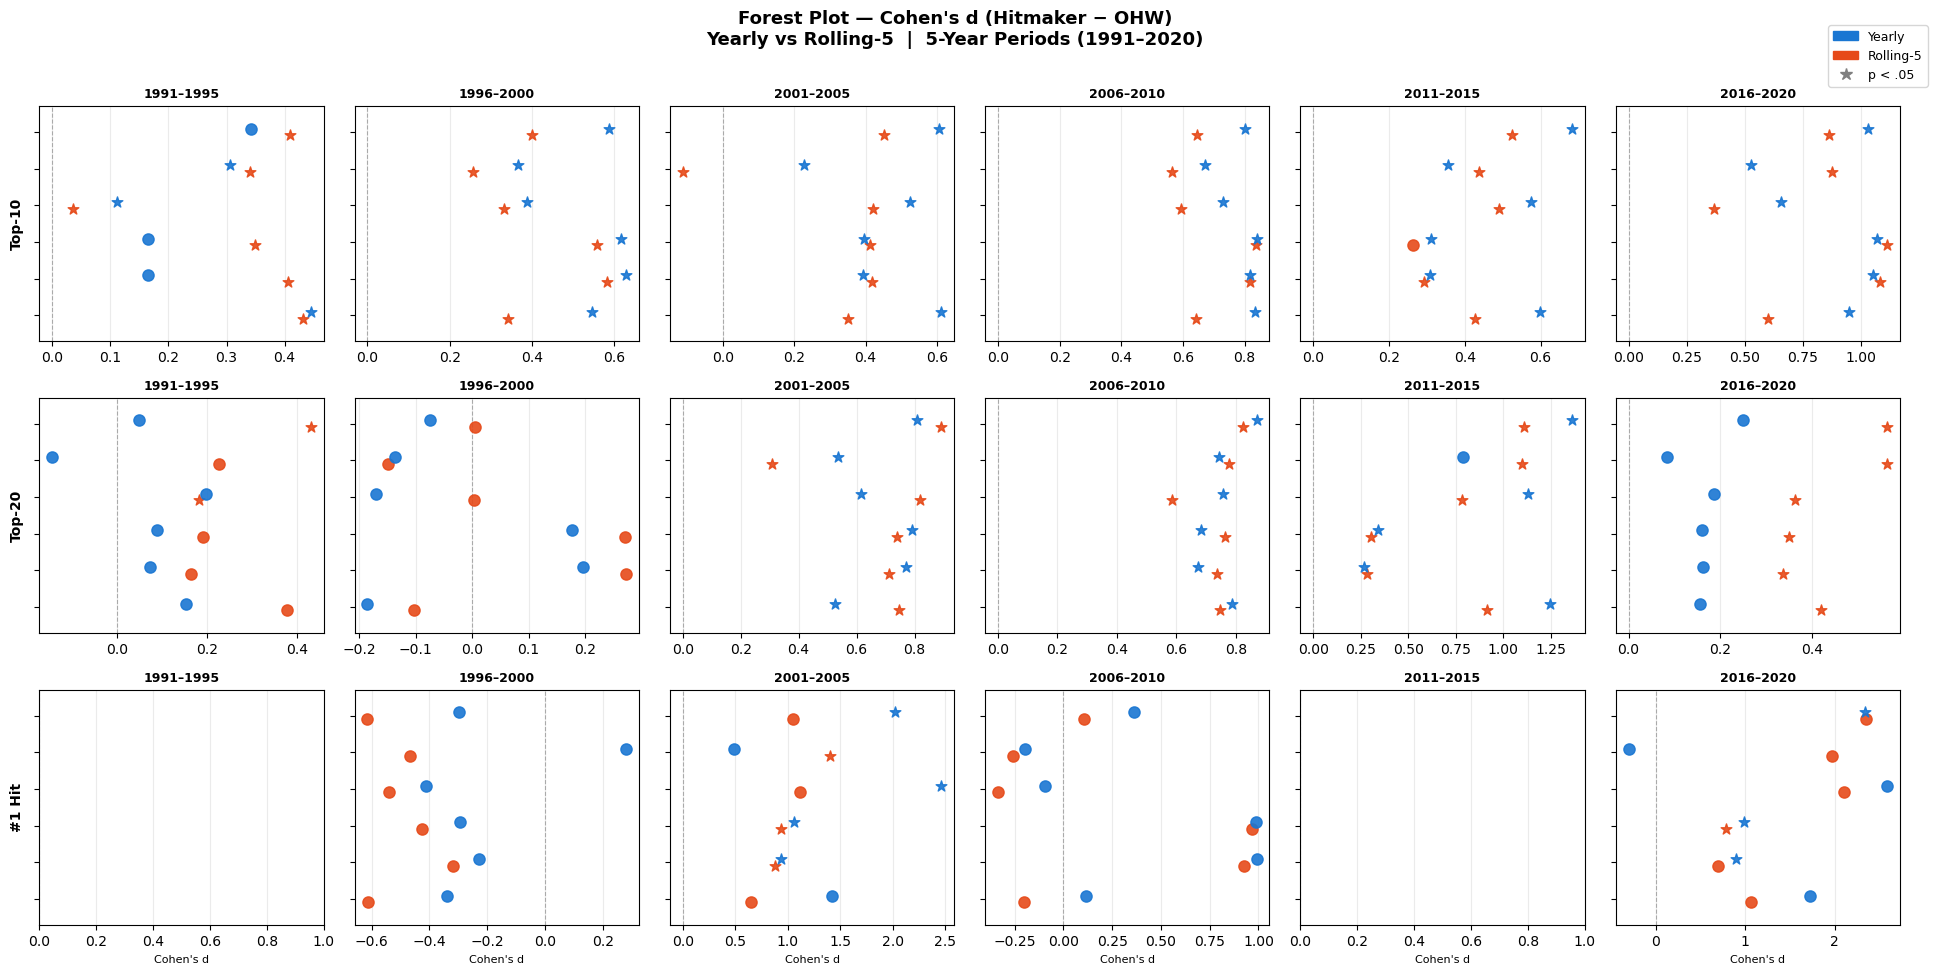

Saved plot_A_forest_5yr.png


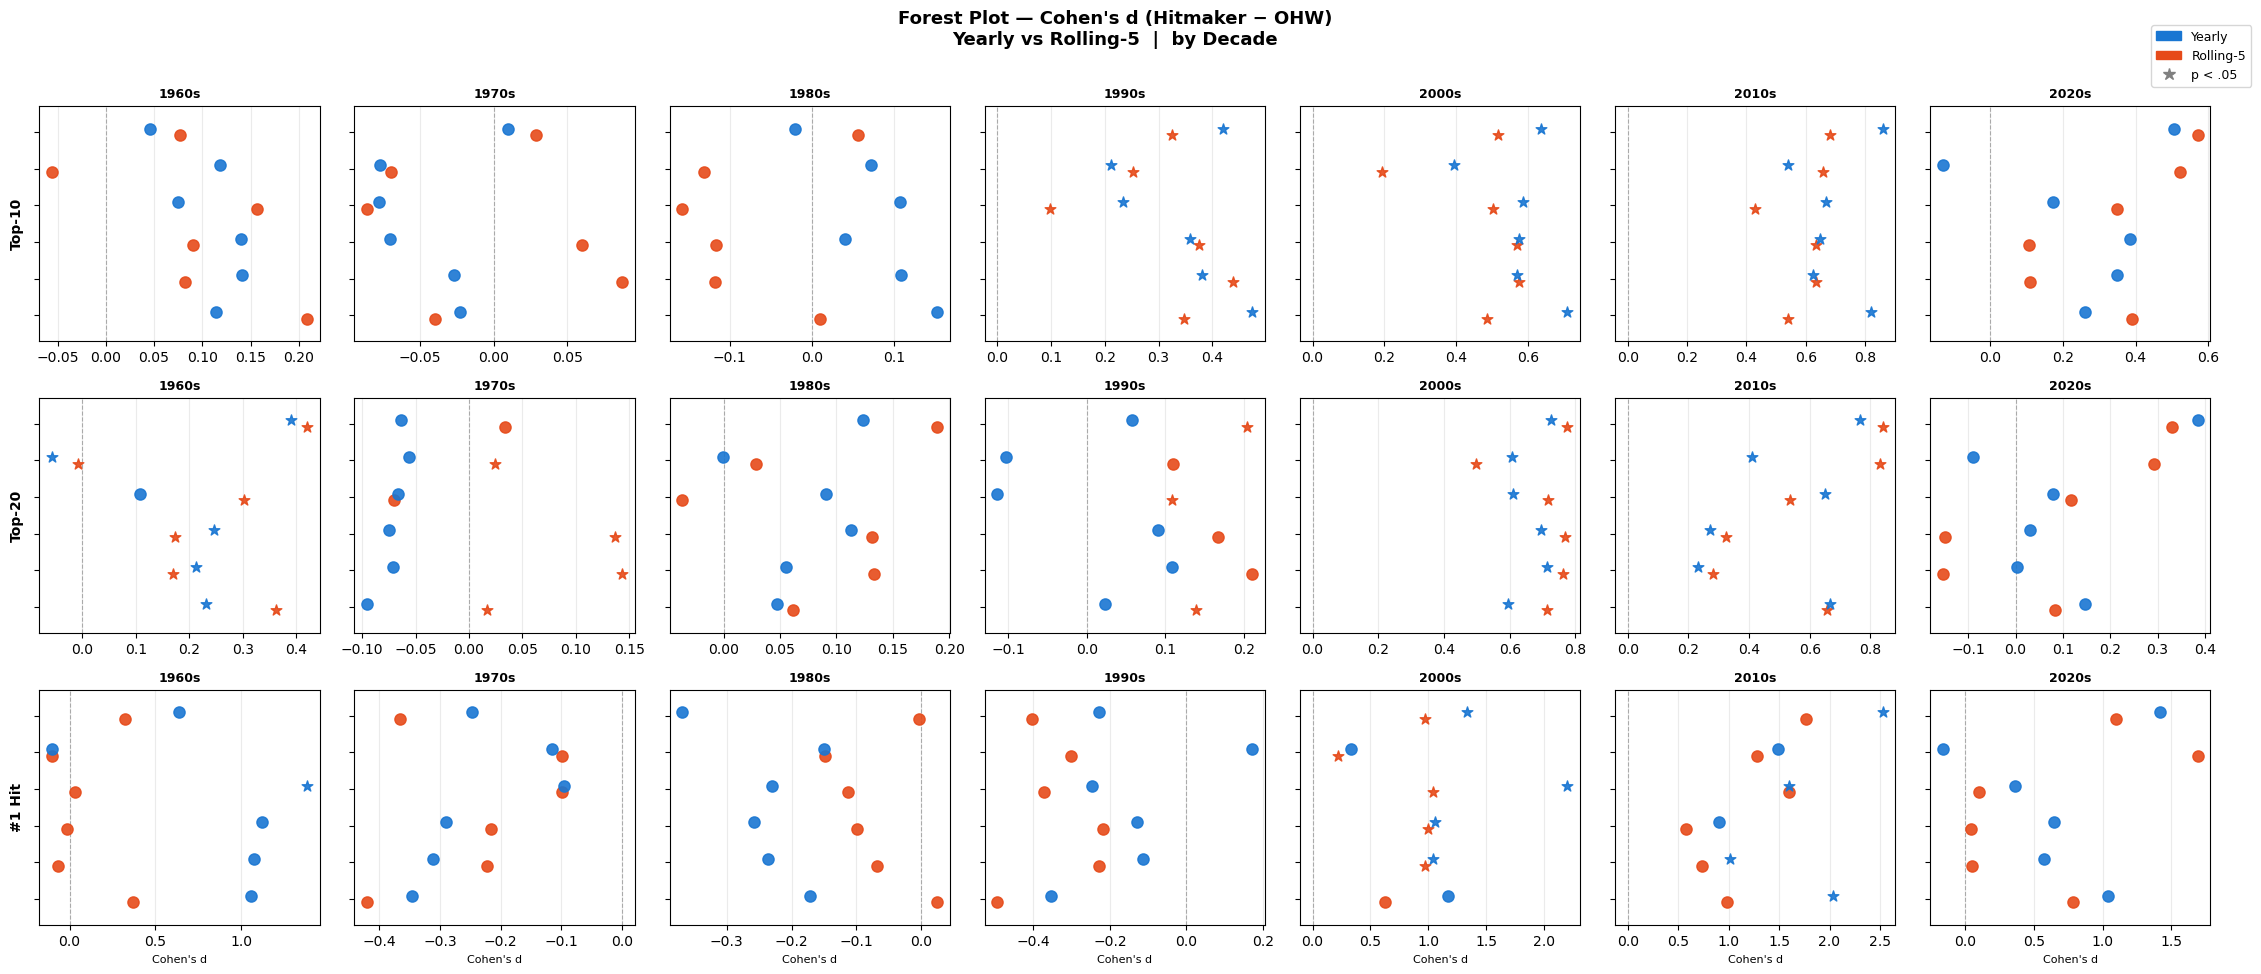

Saved plot_A_forest_decade.png


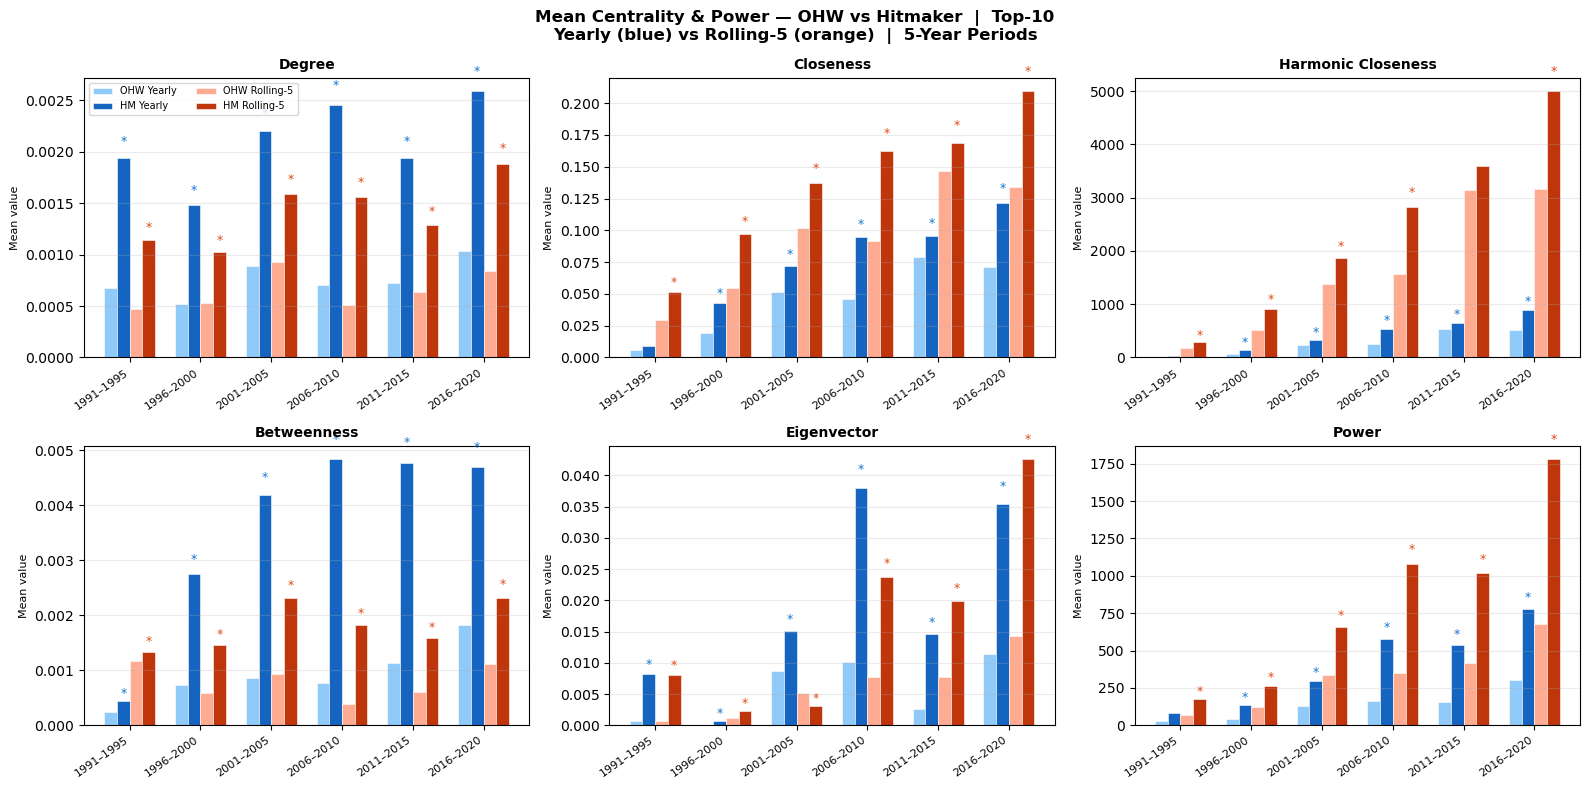

Saved plot_B_bars_Top-10_5yr.png


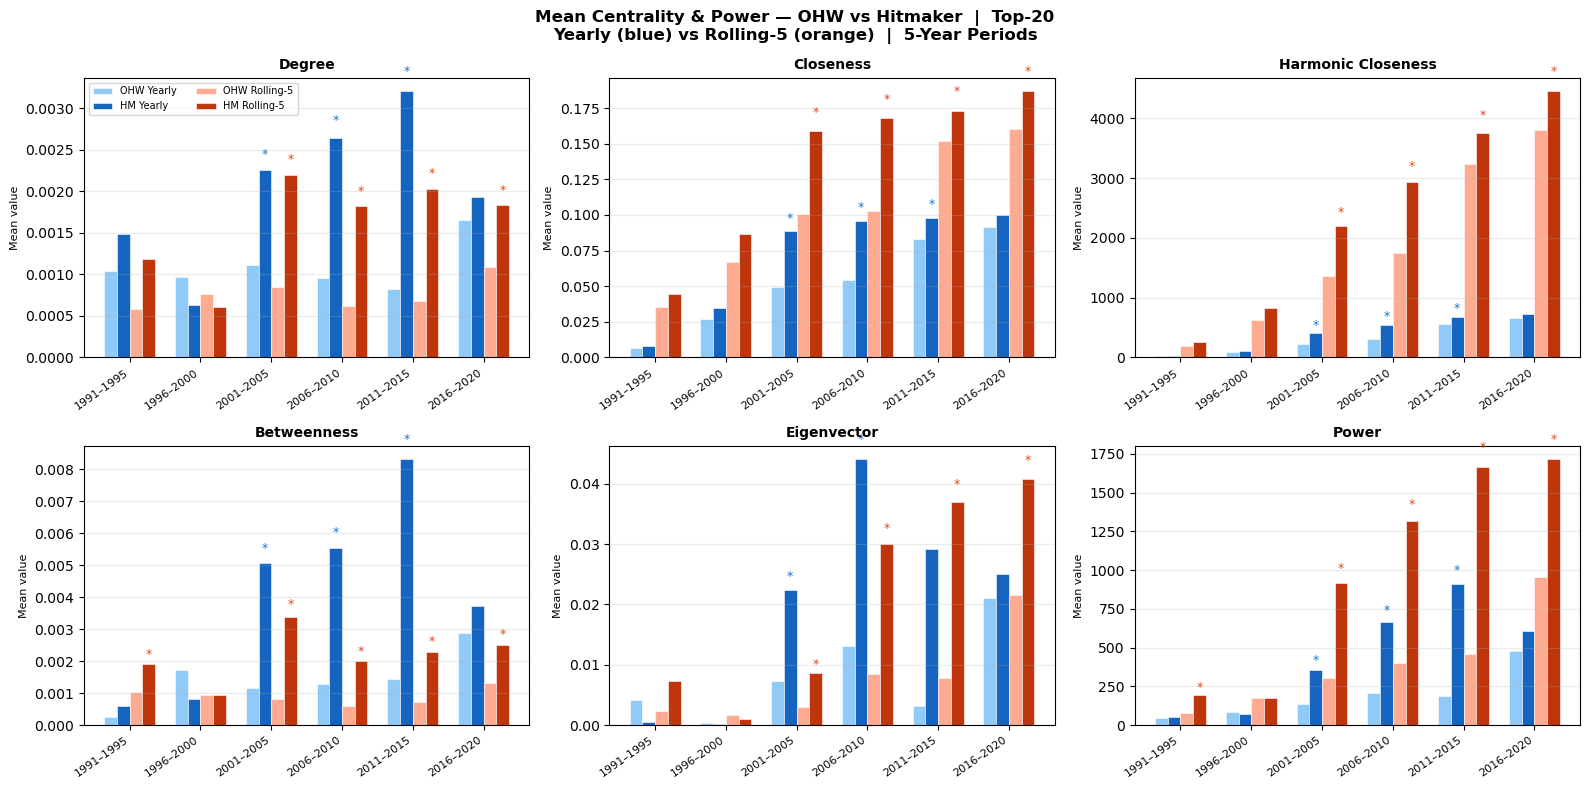

Saved plot_B_bars_Top-20_5yr.png


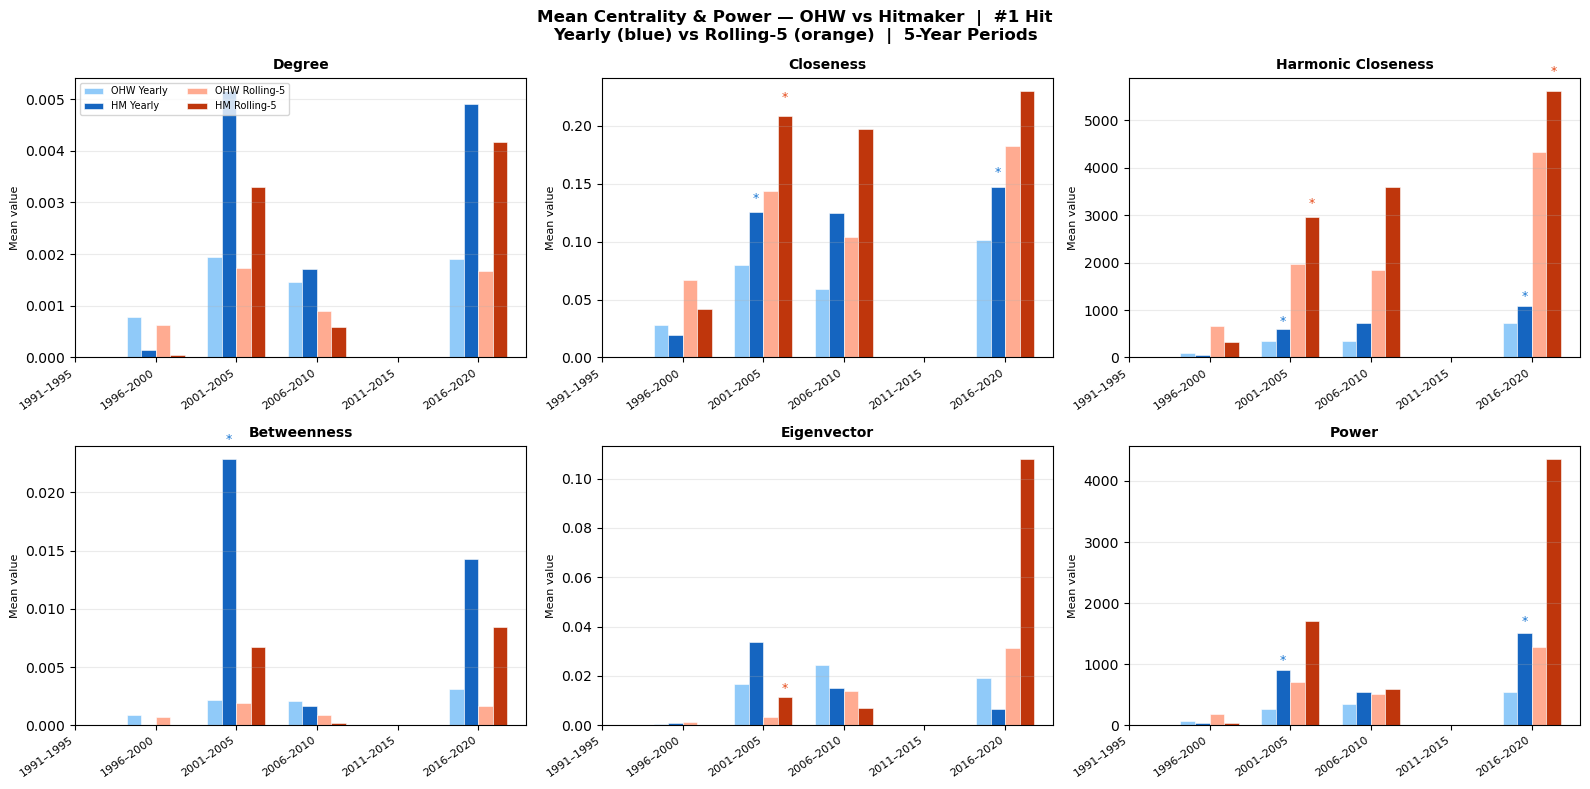

Saved plot_B_bars_num11_Hit_5yr.png


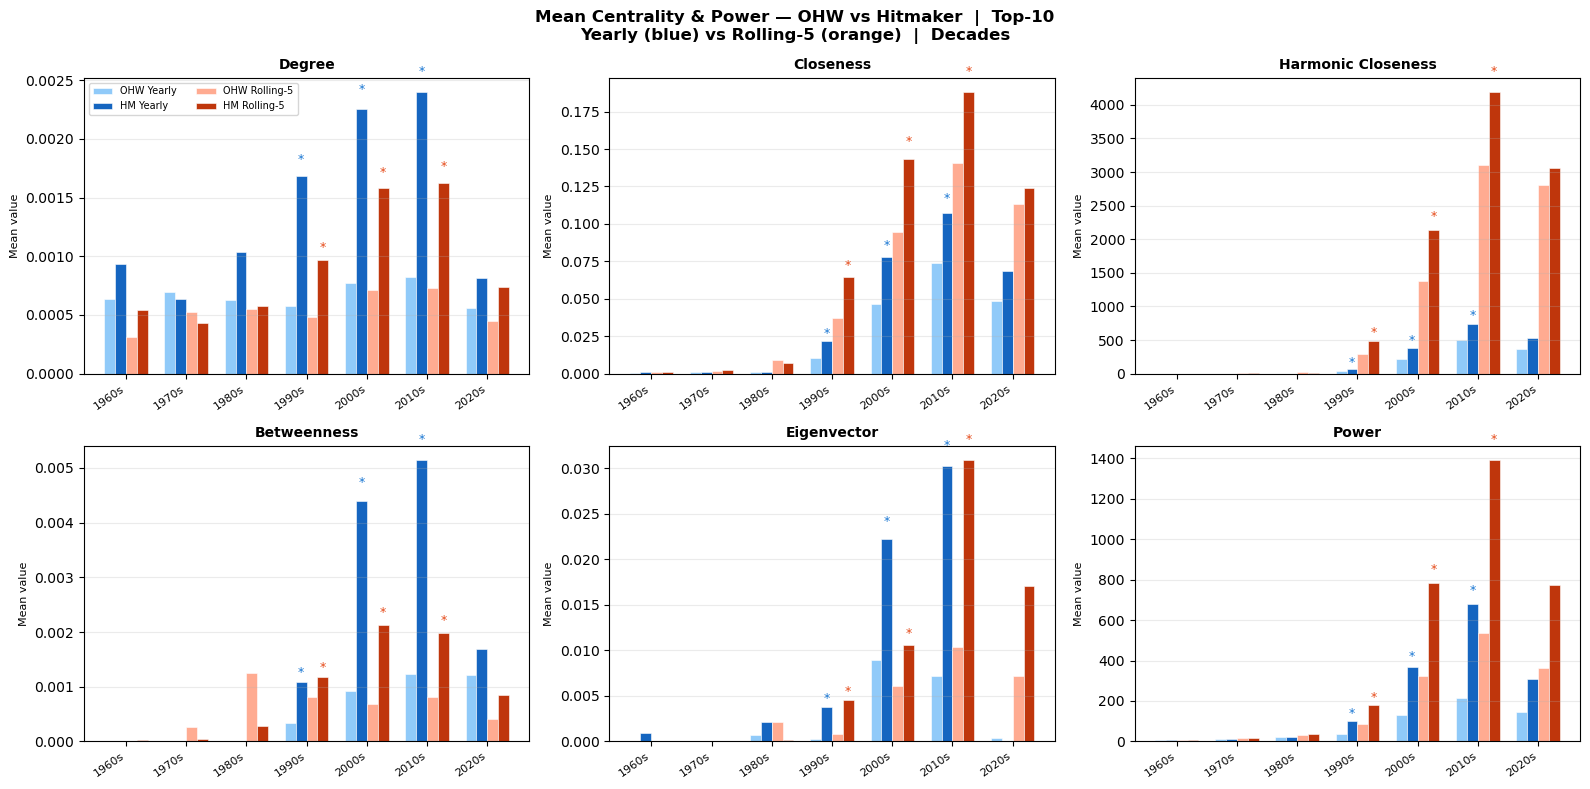

Saved plot_B_bars_Top-10_decade.png


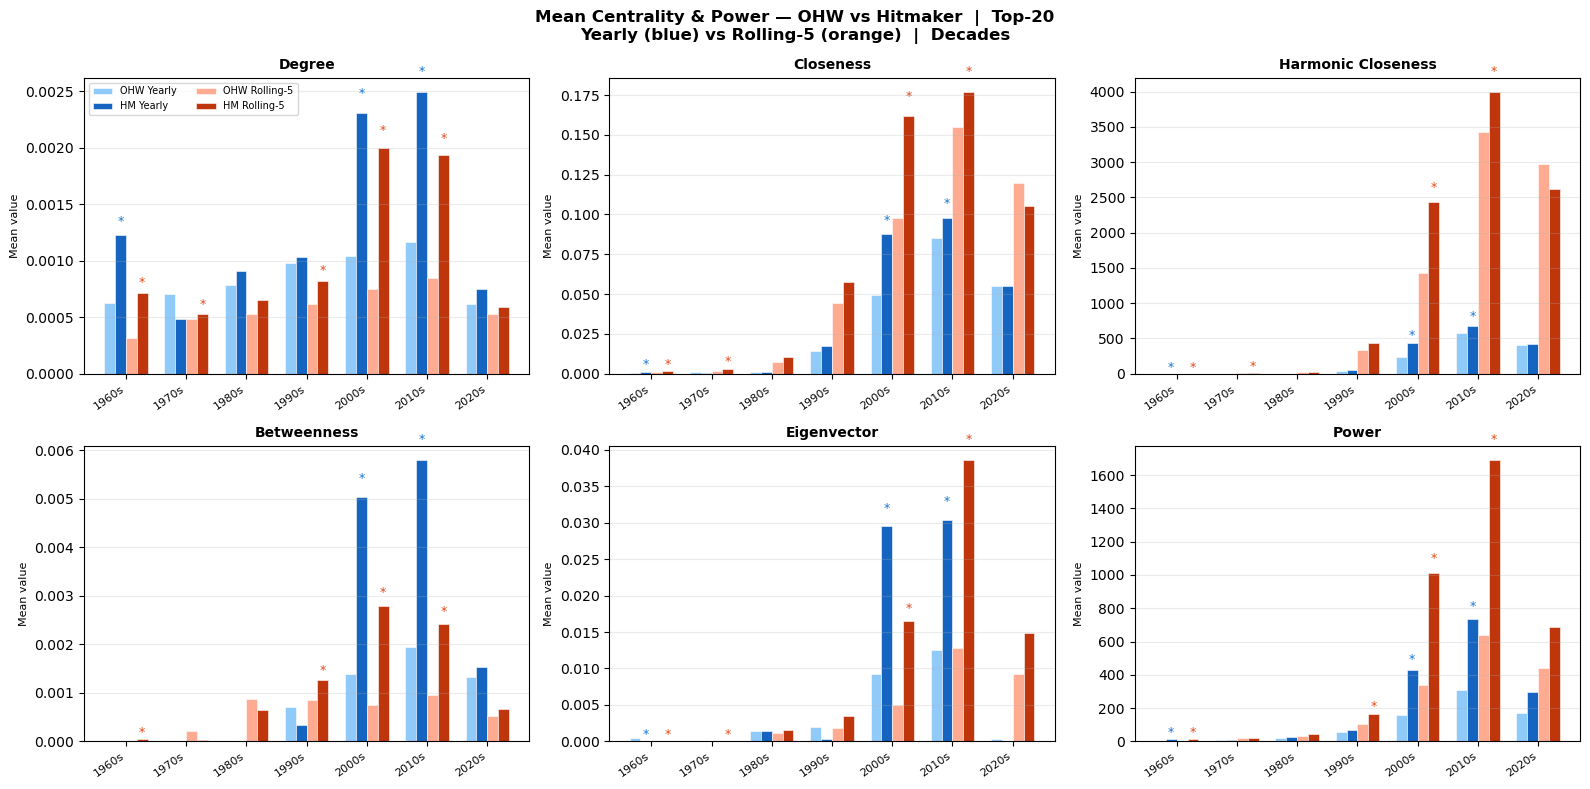

Saved plot_B_bars_Top-20_decade.png


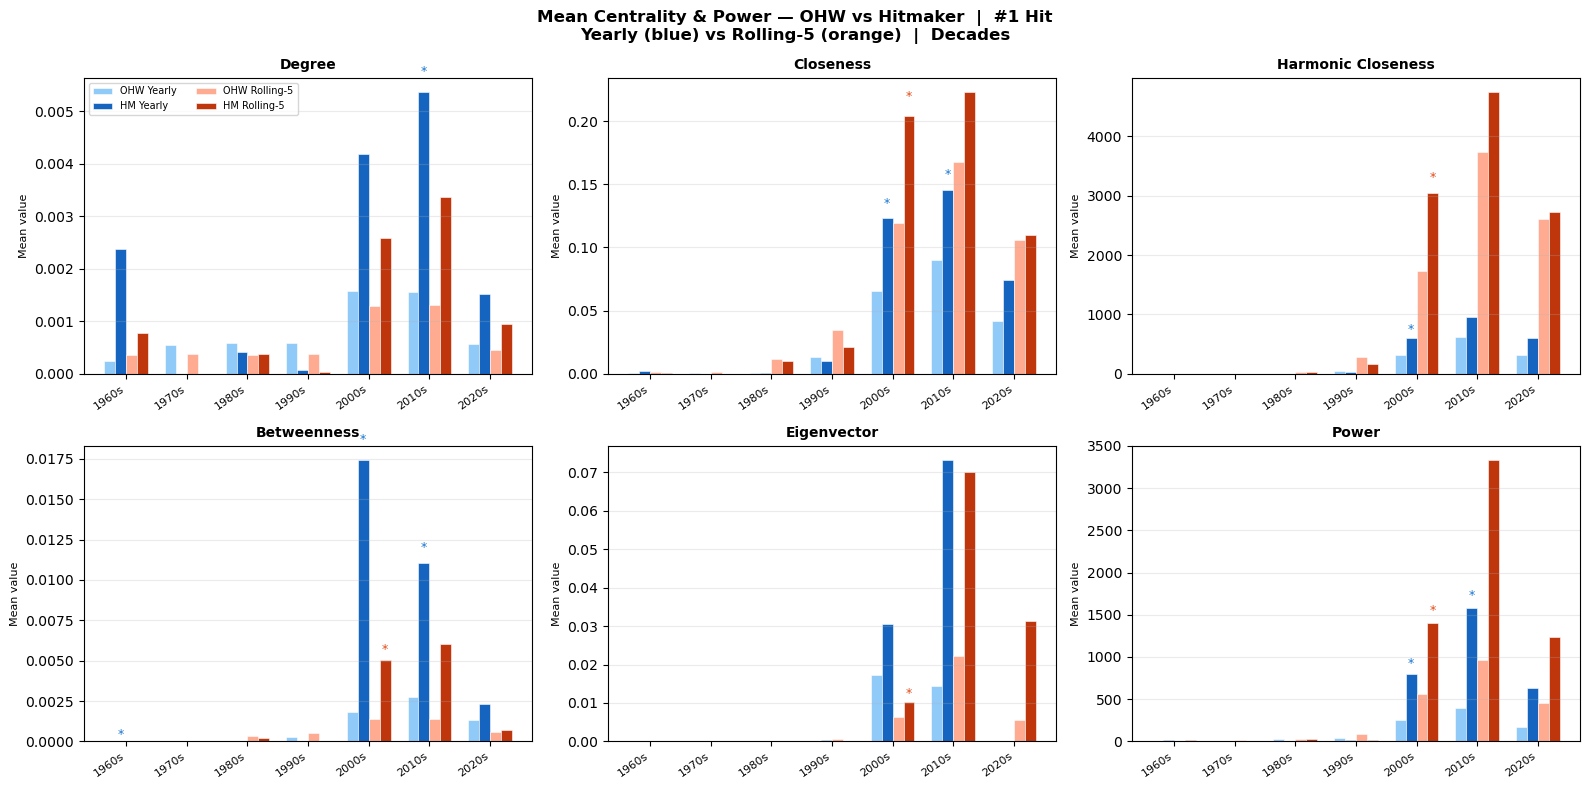

Saved plot_B_bars_num11_Hit_decade.png


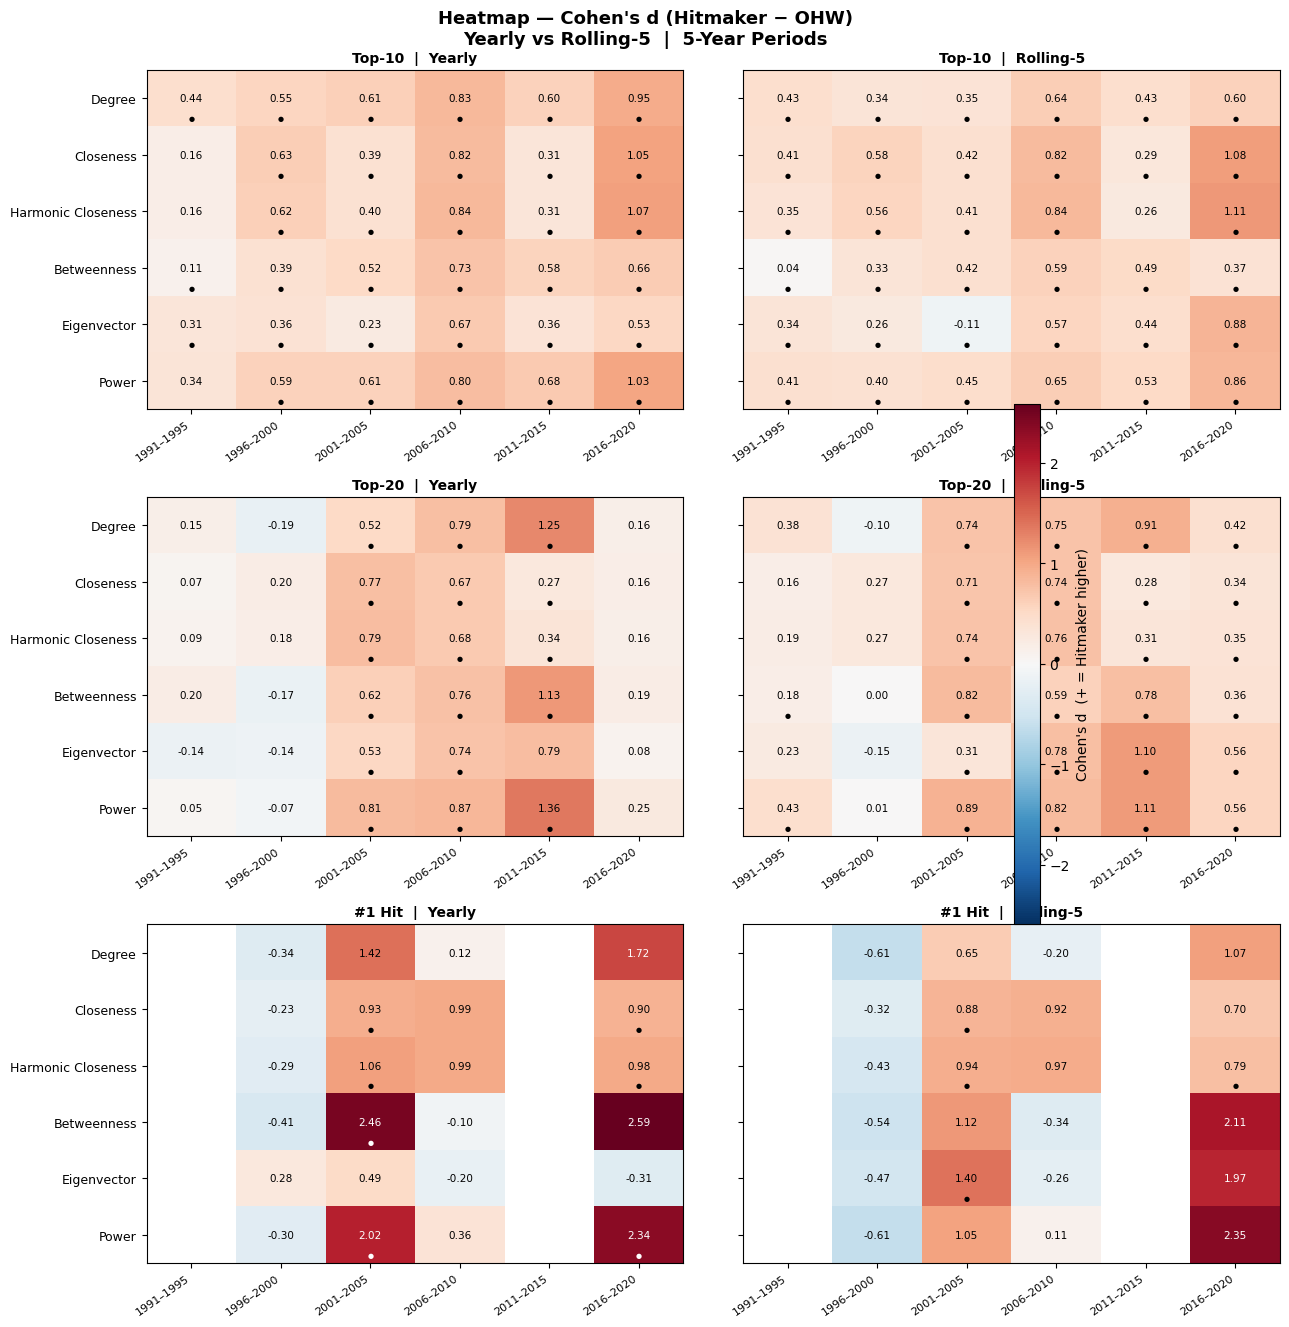

Saved plot_C_heatmap_5yr.png


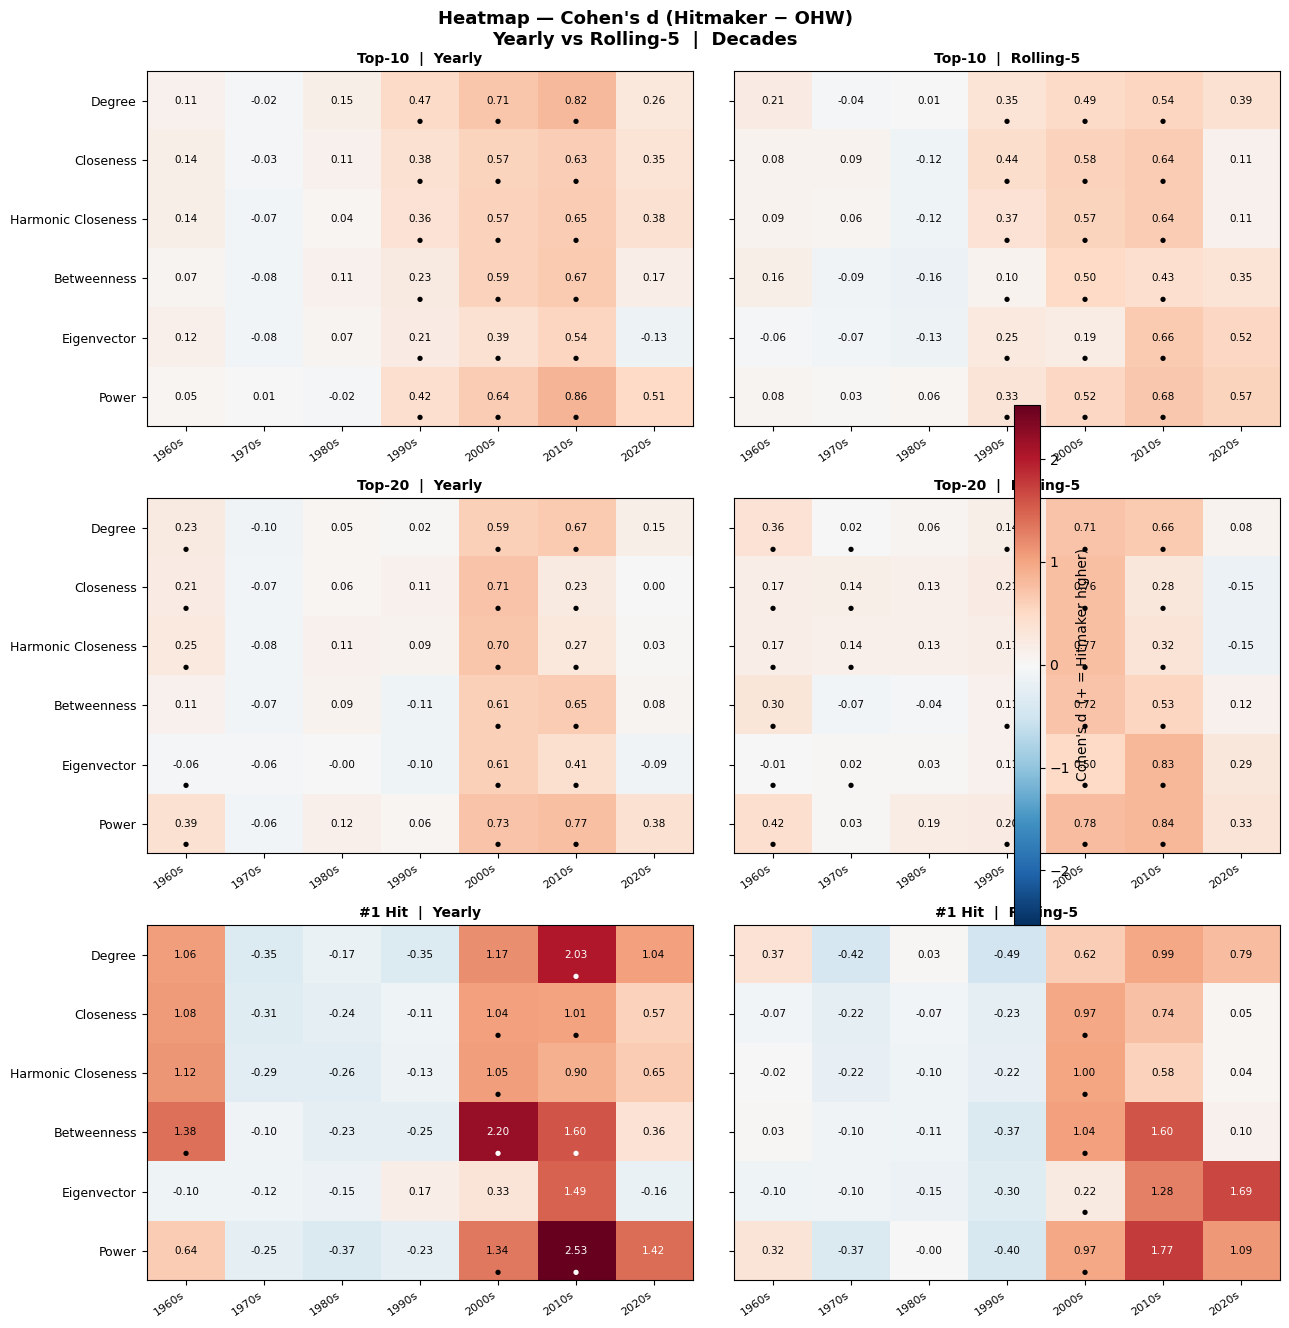

Saved plot_C_heatmap_decade.png

All plots saved.


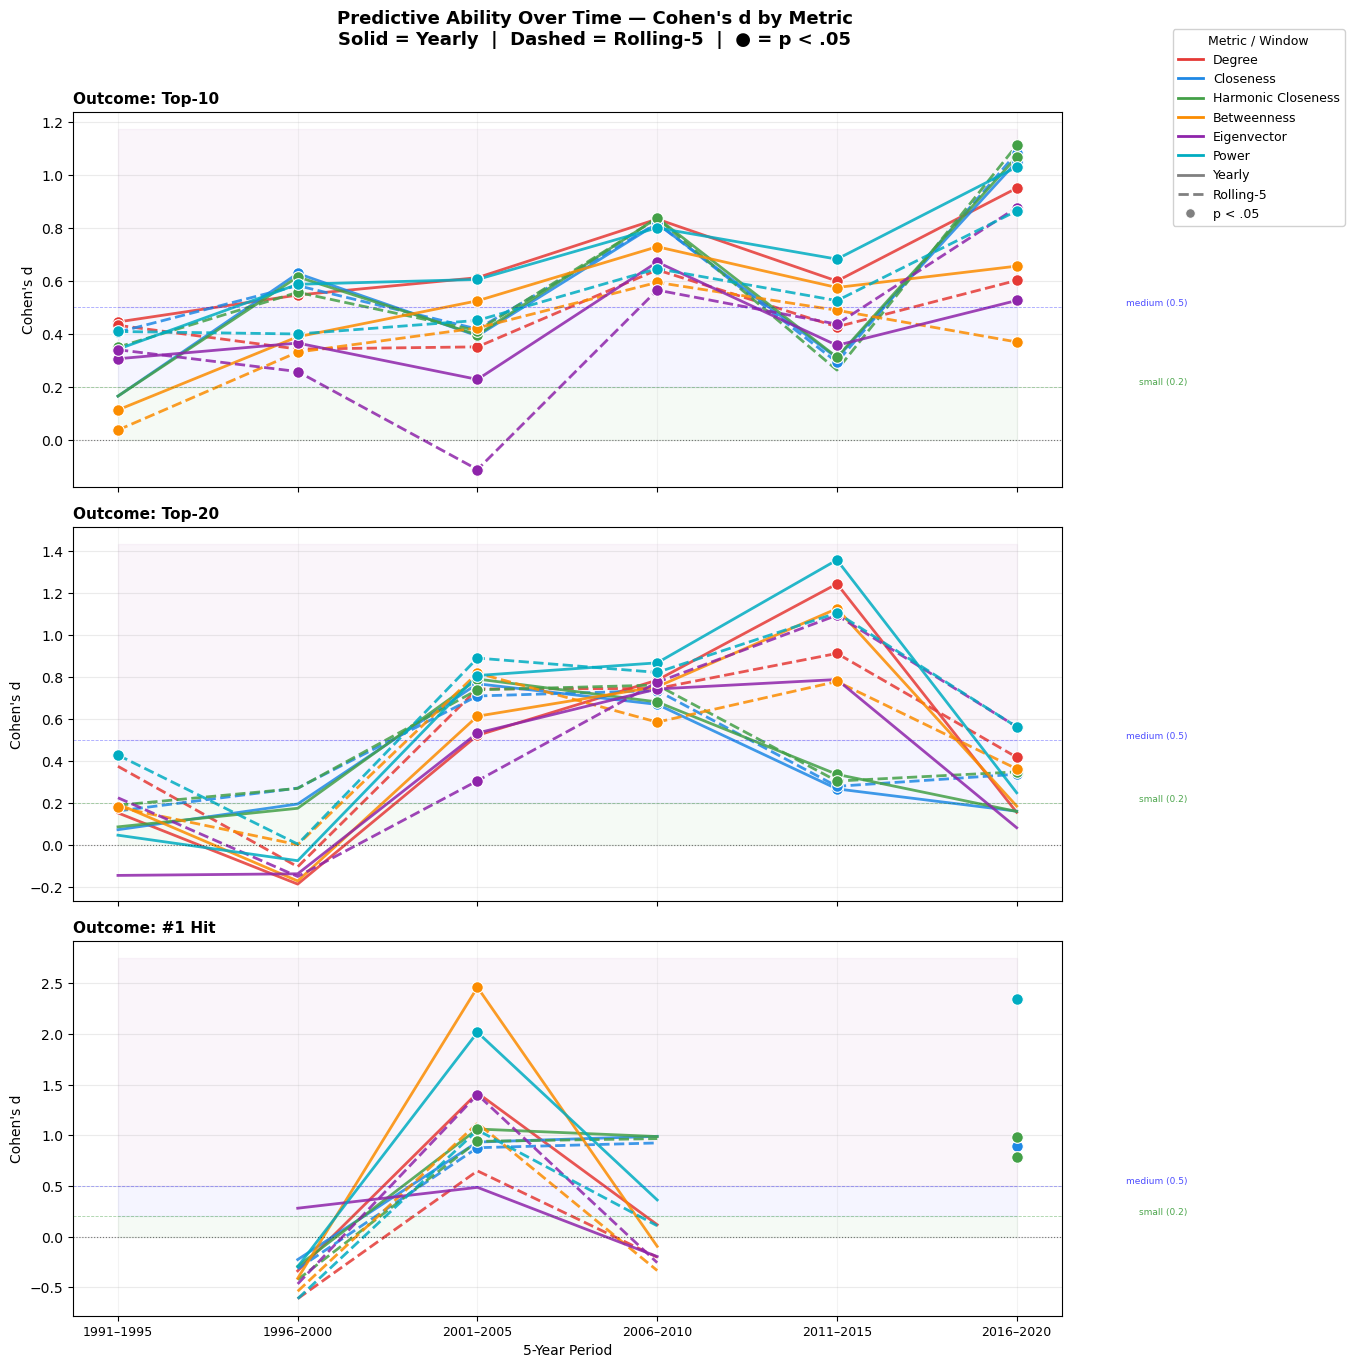

Saved plot_D_lines_5yr.png


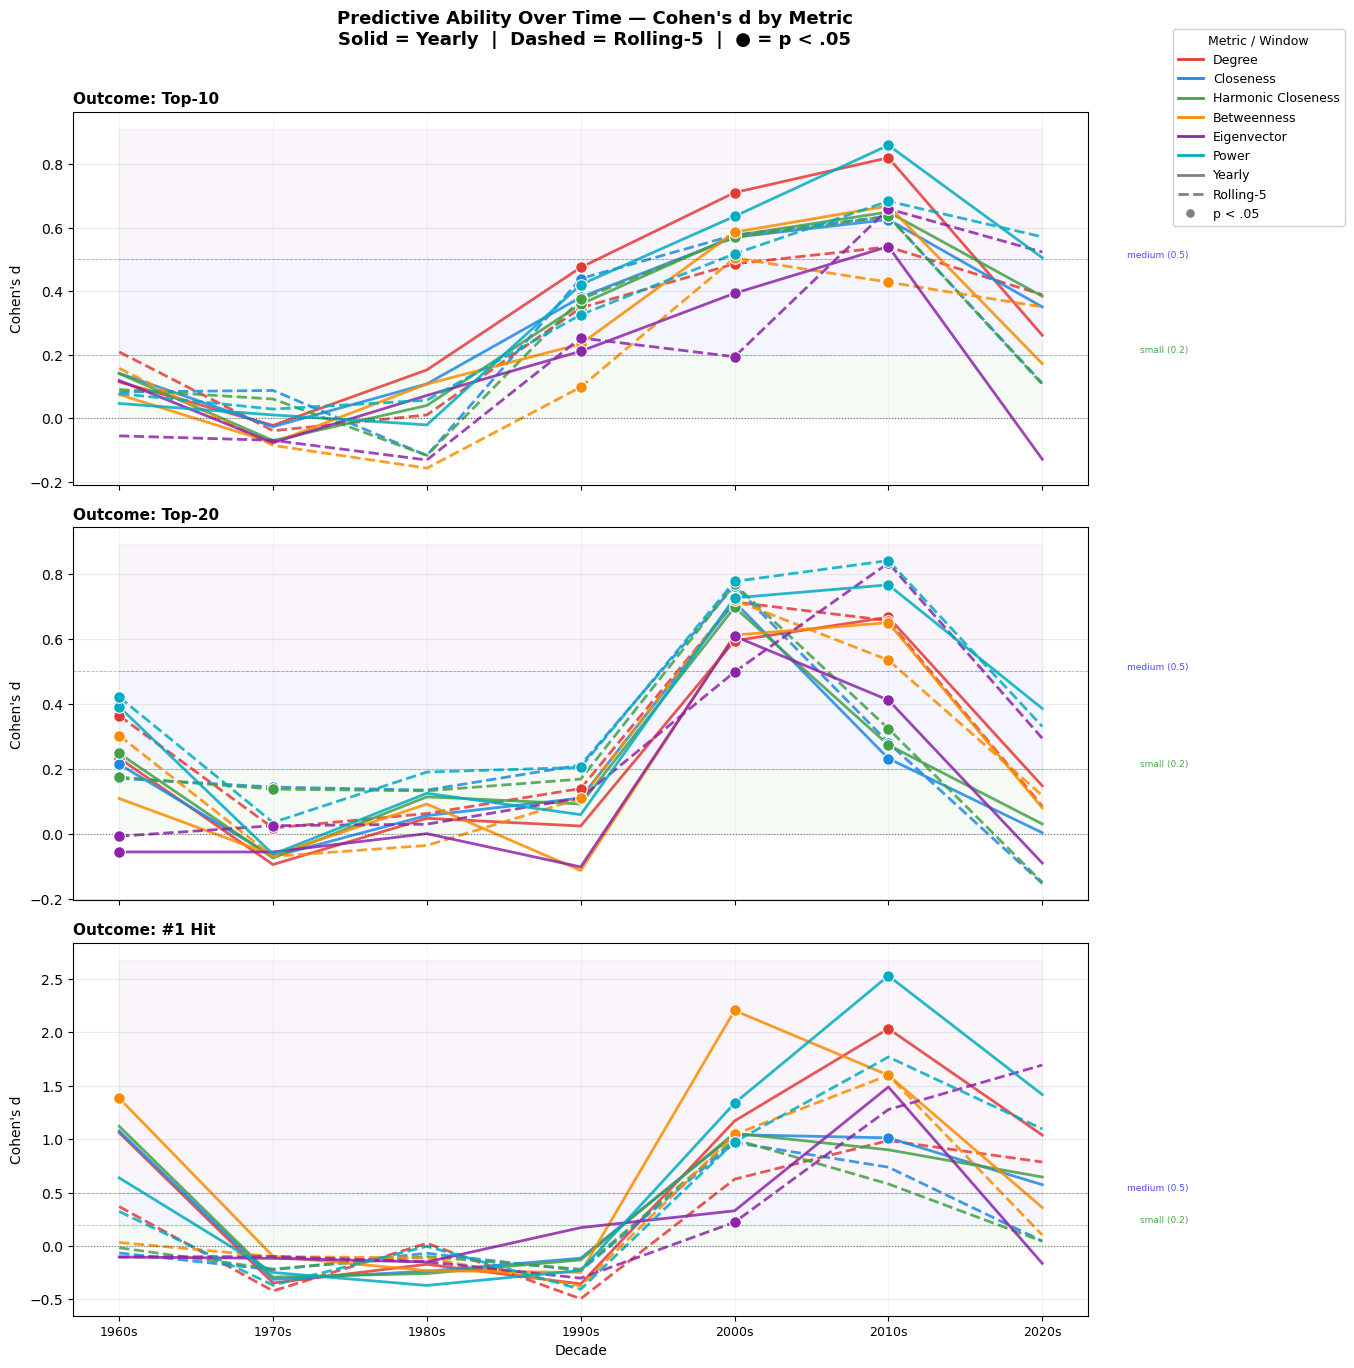

Saved plot_D_lines_decade.png


In [22]:
# ======================================================
# VISUALS: Rolling-5 vs Yearly × OHW / Hitmaker Status
# By 5-Year Period and Decade
# ======================================================

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd

# Uses df_all and run_analysis from the stats cell above
# ── Shared config ─────────────────────────────────────────────
WIN_COLOR  = {'Yearly': '#1976D2', 'Rolling-5': '#E64A19'}
OHW_COLOR  = {'Yearly': '#90CAF9', 'Rolling-5': '#FFAB91'}
HM_COLOR   = {'Yearly': '#1565C0', 'Rolling-5': '#BF360C'}
OUTCOMES   = ['Top-10', 'Top-20', '#1 Hit']
PERIODS_5  = [f'{s}–{e}' for s,e in [(1991,1995),(1996,2000),(2001,2005),
                                       (2006,2010),(2011,2015),(2016,2020)]]
DECADES    = ['1960s','1970s','1980s','1990s','2000s','2010s','2020s']

# ── Re-run analysis for decades ───────────────────────────────
decade_rows = []
for ohw_col, hm_col, outcome_lbl in outcomes:
    for win_key, win_lbl in windows:
        res = run_analysis(df, ohw_col, hm_col, decades, decade_labels, win_key)
        if not res.empty:
            res['Outcome'] = outcome_lbl
            res['Window']  = win_lbl
            decade_rows.append(res)
df_decades = pd.concat(decade_rows, ignore_index=True)

# ══════════════════════════════════════════════════════════════
# PLOT A — FOREST PLOT: Cohen's d, Yearly vs Rolling-5
# ══════════════════════════════════════════════════════════════

for df_plot, time_periods, title_suffix in [
        (df_all,     PERIODS_5, '5-Year Periods (1991–2020)'),
        (df_decades, DECADES,   'by Decade')]:

    n_outcomes = len(OUTCOMES)
    n_periods  = len(time_periods)
    fig, axes  = plt.subplots(n_outcomes, n_periods,
                               figsize=(3.2 * n_periods, 3.2 * n_outcomes),
                               sharey='row')
    fig.suptitle(f"Forest Plot — Cohen's d (Hitmaker − OHW)\n"
                 f"Yearly vs Rolling-5  |  {title_suffix}",
                 fontsize=13, fontweight='bold', y=1.01)

    mlbls = ['Degree','Closeness','Harmonic\nCloseness',
             'Betweenness','Eigenvector','Power']
    ypos  = np.arange(len(mlbls))

    for r, outcome_lbl in enumerate(OUTCOMES):
        for c, period_lbl in enumerate(time_periods):
            ax = axes[r, c]
            sub = df_plot[(df_plot.Outcome == outcome_lbl) &
                          (df_plot.Period  == period_lbl)]
            for j, (win_key, win_lbl) in enumerate(windows[::-1]):
                wdata = sub[sub.Window == win_lbl].set_index('Metric')
                for k, mlbl in enumerate(mlbls):
                    mlbl_clean = mlbl.replace('\n',' ')
                    if mlbl_clean not in wdata.index: continue
                    row_d = wdata.loc[mlbl_clean]
                    d, p  = row_d['Cohen d'], row_d['p-value']
                    if pd.isna(d): continue
                    offset = 0.18 * (j - 0.5)
                    marker = '*' if p < 0.05 else 'o'
                    ax.scatter(d, k + offset,
                               color=WIN_COLOR[win_lbl],
                               marker=marker, s=65, zorder=3, alpha=0.9)

            ax.axvline(0, color='gray', lw=0.8, ls='--', alpha=0.6)
            ax.set_yticks(ypos)
            ax.set_yticklabels(mlbls if c == 0 else [], fontsize=8)
            ax.set_title(period_lbl, fontsize=9, fontweight='bold')
            ax.set_ylim(-0.7, len(mlbls) - 0.3)
            ax.grid(axis='x', alpha=0.25)
            if r == n_outcomes - 1:
                ax.set_xlabel("Cohen's d", fontsize=8)
            if c == 0:
                ax.set_ylabel(outcome_lbl, fontsize=10, fontweight='bold')

    handles = [mpatches.Patch(color=WIN_COLOR[win_lbl], label=win_lbl)
               for _, win_lbl in windows]
    handles.append(plt.Line2D([],[],marker='*',color='gray',ls='none',
                               ms=9, label='p < .05'))
    fig.legend(handles=handles, loc='upper right',
               fontsize=9, bbox_to_anchor=(1.01, 1.0))
    plt.tight_layout()
    fname = f'plot_A_forest_{"5yr" if "5-Year" in title_suffix else "decade"}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved {fname}")

# ══════════════════════════════════════════════════════════════
# PLOT B — BAR CHARTS: Mean OHW vs HM, both windows
# ══════════════════════════════════════════════════════════════

for df_plot, time_periods, time_tag in [
        (df_all,     PERIODS_5, '5yr'),
        (df_decades, DECADES,   'decade')]:

    for ohw_col, hm_col, outcome_lbl in outcomes:
        fig, axes = plt.subplots(2, 3, figsize=(16, 8))
        fig.suptitle(
            f"Mean Centrality & Power — OHW vs Hitmaker  |  {outcome_lbl}\n"
            f"Yearly (blue) vs Rolling-5 (orange)  |  "
            f"{'5-Year Periods' if time_tag=='5yr' else 'Decades'}",
            fontsize=12, fontweight='bold')
        axes = axes.flatten()
        x    = np.arange(len(time_periods))
        bw   = 0.18

        sub_out = df_plot[df_plot.Outcome == outcome_lbl]

        for i, (mlbl_clean, mlbl_axis) in enumerate(
                zip(['Degree','Closeness','Harmonic Closeness',
                     'Betweenness','Eigenvector','Power'],
                    ['Degree','Closeness','Harmonic\nCloseness',
                     'Betweenness','Eigenvector','Power'])):
            ax  = axes[i]
            sub = sub_out[sub_out.Metric == mlbl_clean]

            for j, (group, win_lbl, color) in enumerate([
                    ('OHW', 'Yearly',    OHW_COLOR['Yearly']),
                    ('HM',  'Yearly',    HM_COLOR['Yearly']),
                    ('OHW', 'Rolling-5', OHW_COLOR['Rolling-5']),
                    ('HM',  'Rolling-5', HM_COLOR['Rolling-5']),
            ]):
                col_key = 'Mean OHW' if group == 'OHW' else 'Mean HM'
                vals = [sub[(sub.Window == win_lbl) & (sub.Period == p)][col_key].values
                        for p in time_periods]
                vals = [v[0] if len(v) else np.nan for v in vals]
                ax.bar(x + (j - 1.5) * bw, vals, bw,
                       color=color, label=f"{group} {win_lbl}",
                       edgecolor='white', linewidth=0.4)

                if group == 'HM':
                    for pi, period_lbl in enumerate(time_periods):
                        p_row = sub[(sub.Window == win_lbl) &
                                    (sub.Period  == period_lbl)]
                        if len(p_row) and p_row['p-value'].values[0] < 0.05:
                            bar_h = vals[pi] if not np.isnan(vals[pi]) else 0
                            ax.text(pi + (j - 1.5) * bw, bar_h * 1.05,
                                    '*', ha='center', va='bottom',
                                    fontsize=9, color=WIN_COLOR[win_lbl])

            ax.set_title(mlbl_axis.replace('\n',' '),
                         fontsize=10, fontweight='bold')
            ax.set_xticks(x)
            ax.set_xticklabels(time_periods, rotation=35, ha='right', fontsize=8)
            ax.set_ylabel('Mean value', fontsize=8)
            ax.grid(axis='y', alpha=0.25)
            if i == 0:
                ax.legend(fontsize=7, ncol=2, loc='upper left')

        plt.tight_layout()
        safe  = outcome_lbl.replace(' ','_').replace('#','num1')
        fname = f'plot_B_bars_{safe}_{time_tag}.png'
        plt.savefig(fname, dpi=150, bbox_inches='tight')
        plt.show()
        print(f"Saved {fname}")

# ══════════════════════════════════════════════════════════════
# PLOT C — HEATMAP: Cohen's d across metrics × periods
# ══════════════════════════════════════════════════════════════

for df_plot, time_periods, time_tag, title_suffix in [
        (df_all,     PERIODS_5, '5yr',    '5-Year Periods'),
        (df_decades, DECADES,   'decade', 'Decades')]:

    mlbl_list = ['Degree','Closeness','Harmonic Closeness',
                 'Betweenness','Eigenvector','Power']

    vmax = df_plot['Cohen d'].abs().max(skipna=True)
    norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
    cmap = 'RdBu_r'

    fig, axes = plt.subplots(len(OUTCOMES), 2,
                              figsize=(13, 4.5 * len(OUTCOMES)))
    fig.suptitle(f"Heatmap — Cohen's d (Hitmaker − OHW)\n"
                 f"Yearly vs Rolling-5  |  {title_suffix}",
                 fontsize=13, fontweight='bold')

    for r, outcome_lbl in enumerate(OUTCOMES):
        for c, (win_key, win_lbl) in enumerate(windows):
            ax  = axes[r, c]
            sub = df_plot[(df_plot.Outcome == outcome_lbl) &
                          (df_plot.Window  == win_lbl)]

            matrix = np.full((len(mlbl_list), len(time_periods)), np.nan)
            pmat   = np.full_like(matrix, np.nan)
            for mi, mlbl in enumerate(mlbl_list):
                for pi, period_lbl in enumerate(time_periods):
                    row = sub[(sub.Metric == mlbl) & (sub.Period == period_lbl)]
                    if len(row):
                        matrix[mi, pi] = row['Cohen d'].values[0]
                        pmat[mi, pi]   = row['p-value'].values[0]

            im = ax.imshow(matrix, cmap=cmap, norm=norm, aspect='auto')

            for mi in range(len(mlbl_list)):
                for pi in range(len(time_periods)):
                    v, p = matrix[mi, pi], pmat[mi, pi]
                    if np.isnan(v): continue
                    txt_color = 'white' if abs(v) > vmax * 0.55 else 'black'
                    ax.text(pi, mi, f'{v:.2f}', ha='center', va='center',
                            fontsize=7.5, color=txt_color)
                    if not np.isnan(p) and p < 0.05:
                        ax.text(pi, mi + 0.35, '●', ha='center',
                                va='center', fontsize=5,
                                color='white' if abs(v) > vmax * 0.55 else 'black')

            ax.set_xticks(range(len(time_periods)))
            ax.set_xticklabels(time_periods, rotation=35, ha='right', fontsize=8)
            ax.set_yticks(range(len(mlbl_list)))
            ax.set_yticklabels(mlbl_list if c == 0 else [], fontsize=9)
            ax.set_title(f'{outcome_lbl}  |  {win_lbl}',
                         fontsize=10, fontweight='bold')

    fig.colorbar(im, ax=axes, location='right', shrink=0.5,
                 label="Cohen's d  (+ = Hitmaker higher)")
    plt.tight_layout()
    fname = f'plot_C_heatmap_{time_tag}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved {fname}")

print("\nAll plots saved.")

# ══════════════════════════════════════════════════════════════
# PLOT D — LINE GRAPH: Predictive Ability Over Time
# Cohen's d per metric across time periods
# ══════════════════════════════════════════════════════════════
#
# Each line = one centrality metric or power.
# Y-axis = Cohen's d (effect size separating OHW from hitmakers).
# Higher = that metric is better at predicting hitmaker status
# in that period. Dashed line at 0 = no predictive ability.
# Solid lines = yearly window; dashed lines = rolling-5.
# Filled dots = statistically significant (p < .05).
# ══════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np
import pandas as pd

METRIC_COLORS = {
    'Degree':             '#E53935',
    'Closeness':          '#1E88E5',
    'Harmonic Closeness': '#43A047',
    'Betweenness':        '#FB8C00',
    'Eigenvector':        '#8E24AA',
    'Power':              '#00ACC1',
}
METRIC_ORDER = list(METRIC_COLORS.keys())

def get_line(df_res, outcome, window, metric, time_periods):
    sub = df_res[(df_res.Outcome == outcome) &
                 (df_res.Window  == window)  &
                 (df_res.Metric  == metric)]
    return [sub[sub.Period == p]['Cohen d'].values[0]
            if len(sub[sub.Period == p]) else np.nan
            for p in time_periods]

def get_sig(df_res, outcome, window, metric, time_periods):
    sub = df_res[(df_res.Outcome == outcome) &
                 (df_res.Window  == window)  &
                 (df_res.Metric  == metric)]
    return [sub[sub.Period == p]['p-value'].values[0]
            if len(sub[sub.Period == p]) else np.nan
            for p in time_periods]

for df_plot, time_periods, time_tag, xtitle in [
        (df_all,     PERIODS_5, '5yr',    '5-Year Period'),
        (df_decades, DECADES,   'decade', 'Decade')]:

    fig, axes = plt.subplots(len(OUTCOMES), 1,
                              figsize=(12, 4.5 * len(OUTCOMES)),
                              sharex=True)
    fig.suptitle(
        f"Predictive Ability Over Time — Cohen's d by Metric\n"
        f"Solid = Yearly  |  Dashed = Rolling-5  |  ● = p < .05",
        fontsize=13, fontweight='bold', y=1.01)

    x = np.arange(len(time_periods))

    for ax, outcome_lbl in zip(axes, OUTCOMES):
        for metric in METRIC_ORDER:
            color = METRIC_COLORS[metric]
            for win_lbl, linestyle in [('Yearly', '-'), ('Rolling-5', '--')]:
                ys  = get_line(df_plot, outcome_lbl, win_lbl, metric, time_periods)
                sig = get_sig( df_plot, outcome_lbl, win_lbl, metric, time_periods)

                ax.plot(x, ys,
                        color=color, lw=2,
                        linestyle=linestyle, alpha=0.85,
                        label=f'{metric} ({win_lbl})')

                for xi, (y_val, p_val) in enumerate(zip(ys, sig)):
                    if not np.isnan(y_val) and not np.isnan(p_val) and p_val < 0.05:
                        ax.scatter(xi, y_val, color=color, s=70,
                                   zorder=5, edgecolors='white', linewidths=0.8)

        ax.axhline(0, color='black', lw=0.8, ls=':', alpha=0.5)

        # Effect size reference bands
        ymax = max(0.6, ax.get_ylim()[1])
        ax.fill_between(x, 0,   0.2,  alpha=0.04, color='green')
        ax.fill_between(x, 0.2, 0.5,  alpha=0.04, color='blue')
        ax.fill_between(x, 0.5, ymax, alpha=0.04, color='purple')

        ax.set_ylabel("Cohen's d", fontsize=10)
        ax.set_title(f'Outcome: {outcome_lbl}', fontsize=11,
                     fontweight='bold', loc='left')
        ax.set_xticks(x)
        ax.set_xticklabels(time_periods, fontsize=9)
        ax.grid(axis='y', alpha=0.25)
        ax.grid(axis='x', alpha=0.15)

        ylim = ax.get_ylim()
        for label, val, col in [('small (0.2)', 0.2, 'green'),
                                  ('medium (0.5)', 0.5, 'blue')]:
            if ylim[0] < val < ylim[1]:
                ax.axhline(val, color=col, lw=0.6, ls='--', alpha=0.35)
                ax.text(len(time_periods) - 0.05, val, label,
                        fontsize=6.5, color=col,
                        va='bottom', ha='right', alpha=0.7)

    axes[-1].set_xlabel(xtitle, fontsize=10)

    # ── Legend ────────────────────────────────────────────────
    metric_handles = [mlines.Line2D([], [], color=METRIC_COLORS[m],
                                    lw=2, label=m)
                      for m in METRIC_ORDER]
    window_handles = [
        mlines.Line2D([], [], color='gray', lw=2, ls='-',  label='Yearly'),
        mlines.Line2D([], [], color='gray', lw=2, ls='--', label='Rolling-5'),
        mlines.Line2D([], [], color='gray', marker='o', ls='none',
                      ms=7, markeredgecolor='white',
                      markeredgewidth=0.8, label='p < .05'),
    ]
    fig.legend(handles=metric_handles + window_handles,
               loc='upper right', fontsize=9,
               bbox_to_anchor=(1.13, 1.0), framealpha=0.9,
               title='Metric / Window', title_fontsize=9)

    plt.tight_layout()
    fname = f'plot_D_lines_{time_tag}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved {fname}")
